<a href="https://colab.research.google.com/github/konishogu/DeepLearning-SIMPSON/blob/main/DLY01100_EV2_003D_GRUPO_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



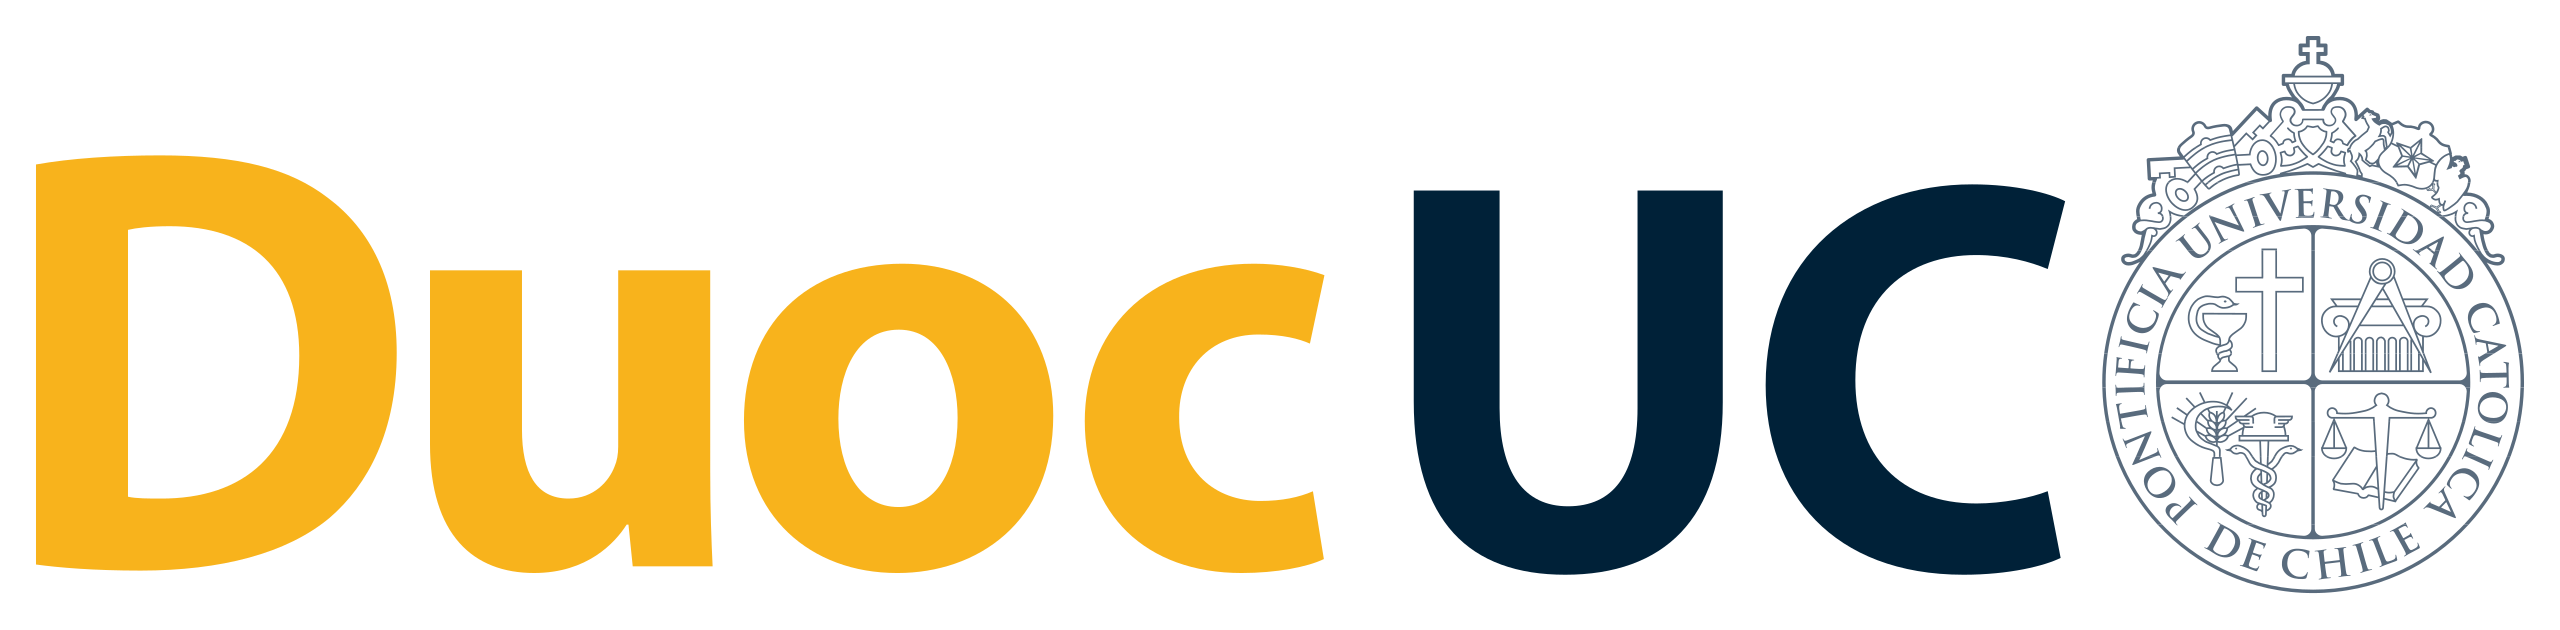



---
**Autores:**

- Matias Ignacio Wastavino Gonzalez
- Luis Rodrigo Nicolas Mendez Lehner
- Rodrigo Antonio Carcamo Rojas
- Matias Ignacio Molina Sepulveda
- Alejandra Ignacia Riquelme Velásquez

**Docente:** Marcelo Alejandro Tapia Contreras

**Asignatura:** Deep learning

**Sección:** 003D

**Institución:** Duoc UC - Sede Melipilla

**Fecha de entrega:** 22 de Mayo de 2026

---

## **1. INTRODUCCIÓN**

Las redes neuronales convolucionales (CNN) representan una de las arquitecturas más utilizadas en tareas de visión computacional y clasificación de imágenes, debido a su capacidad para extraer automáticamente características visuales relevantes. En este trabajo se aborda un problema de clasificación de imágenes utilizando un dataset compuesto por personajes de la serie Los Simpsons. Este conjunto de datos presenta una complejidad mayor en comparación con datasets tradicionales como MNIST o Fashion MNIST, ya que los personajes aparecen en distintas posiciones, poses, escalas e incluso acompañados por otros personajes dentro de la misma imagen. El objetivo principal del trabajo consiste en implementar y optimizar una CNN utilizando TensorFlow/Keras, evaluando distintas arquitecturas e hiperparámetros para alcanzar un rendimiento superior al 85% de accuracy sobre el conjunto de prueba.

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

## **2. IMPORTACIÓN DE LIBRERÍAS**

En esta sección se importan las librerías necesarias para el desarrollo del proyecto de clasificación de imágenes mediante redes neuronales convolucionales (CNN).

In [ ]:
# Librerías para visualización y procesamiento de imágenes
from google.colab.patches import cv2_imshow
import cv2
import os
import glob
import itertools
import collections
import subprocess

# Librerías para manejo numérico y visualización de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# TensorFlow y Keras para construcción de la CNN
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Dense,
    Activation,
    Dropout,
    Flatten,
    BatchNormalization,
    MaxPooling2D,
    Conv2D
)

# Herramientas para preprocesamiento y optimización
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD

# Librerías para evaluación del modelo
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn import metrics
import seaborn as sns
from sklearn.model_selection import train_test_split

## **3. CARGA DEL DATASET**

### **3.1. Creación de directorio**

Antes de descargar el dataset, es necesario crear un directorio de trabajo donde se almacenarán los archivos utilizados durante el desarrollo del proyecto. En Google Colab, el entorno de ejecución es temporal, por lo que cada vez que la máquina virtual se reinicia se eliminan los archivos almacenados anteriormente. Por esta razón, se crea automáticamente la carpeta '/root/.keras/datasets', utilizada por Keras como ubicación estándar para guardar datasets descargados. Esto permite mantener una estructura organizada y asegurar que las imágenes puedan ser encontradas correctamente durante la carga y el entrenamiento del modelo.

In [ ]:
# Crea la carpeta donde se almacenarán los datasets descargados
os.makedirs('/root/.keras/datasets', exist_ok=True)

### **3.2. Descarga de datos**

En esta etapa se descargan los archivos comprimidos que contienen el dataset de entrenamiento y prueba utilizado en el proyecto. Para ello se utiliza la herramienta 'gdown', que permite descargar archivos directamente desde Google Drive mediante un identificador único. Los archivos descargados se almacenan en el directorio creado previamente, permitiendo disponer localmente de las imágenes necesarias para el entrenamiento y evaluación de la red neuronal convolucional.

In [ ]:
# Descarga el dataset de entrenamiento desde Google Drive y lo guarda en el directorio
print("⬇Descargando simpsons_train.tar.gz ...")
!gdown 1snRV751UeWXFVJVgBvhY2pfiqAx_95yS -O /root/.keras/datasets/simpsons_train.tar.gz

# Descarga el dataset de prueba desde Google Drive y lo guarda en el directorio
print("⬇Descargando simpsons_test.tar.gz ...")
!gdown 1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj -O /root/.keras/datasets/simpsons_test.tar.gz

⬇Descargando simpsons_train.tar.gz ...
Downloading...
From: https://drive.google.com/uc?id=1snRV751UeWXFVJVgBvhY2pfiqAx_95yS
To: /root/.keras/datasets/simpsons_train.tar.gz
100% 10.7M/10.7M [00:00<00:00, 39.8MB/s]
⬇Descargando simpsons_test.tar.gz ...
Downloading...
From (original): https://drive.google.com/uc?id=1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj
From (redirected): https://drive.google.com/uc?id=1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj&confirm=t&uuid=b80954ab-e9cb-4a7b-9f5b-c62c09ddda8c
To: /root/.keras/datasets/simpsons_test.tar.gz
100% 524M/524M [00:03<00:00, 172MB/s]


### **3.3. Descomprensión**

Una vez descargados los archivos comprimidos del dataset, es necesario extraer su contenido para poder acceder a las imágenes utilizadas en el entrenamiento y prueba del modelo. Para ello se utiliza el comando 'tar', el cual descomprime los archivos '.tar.gz' y almacena las carpetas resultantes dentro del directorio de trabajo configurado previamente.

In [ ]:
# Descomprime el dataset de entrenamiento dentro del directorio
!tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /root/.keras/datasets --ignore-zeros

# Descomprime el dataset de prueba dentro del directorio
!tar -xzf /root/.keras/datasets/simpsons_test.tar.gz -C /root/.keras/datasets --ignore-zeros

### **3.4. Verificación de archivos**

Después de descargar y descomprimir los datasets, se realiza una verificación del contenido almacenado en el directorio de trabajo. Esto permite comprobar que los archivos y carpetas fueron creados correctamente antes de continuar con la carga y procesamiento de imágenes.

In [ ]:
# Muestra los archivos y carpetas disponibles dentro del directorio
print("\nContenido descargado:")
!ls /root/.keras/datasets/


Contenido descargado:
simpsons  simpsons_testset  simpsons_test.tar.gz  simpsons_train.tar.gz


### **3.5. Configuración del dataset**

Una vez descargado y verificado el dataset, es necesario definir ciertos parámetros que permitirán organizar correctamente la información antes de cargar las imágenes en memoria. En esta etapa se establece la estructura de etiquetas que relaciona cada personaje con un identificador numérico y se define el tamaño estándar al que serán redimensionadas todas las imágenes.

In [ ]:
# Mapeo entre etiquetas numéricas y personajes del dataset
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy',
    6: 'edna_krabappel', 7: 'homer_simpson', 8: 'kent_brockman',
    9: 'krusty_the_clown', 10: 'lisa_simpson', 11: 'marge_simpson',
    12: 'milhouse_van_houten', 13: 'moe_szyslak', 14: 'ned_flanders',
    15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Tamaño estándar utilizado para redimensionar todas las imágenes
IMG_SIZE = 64

## **4. CARGA DE IMÁGENES**

### **4.1. Función de carga de entrenamiento**

In [ ]:
def load_train_set(dirname, map_characters, verbose=True):

    # Lista donde se almacenarán las imágenes
    X_train = []
    # Lista donde se almacenarán las etiquetas
    y_train = []

    # Recorre cada personaje y su etiqueta numérica
    for label, character in map_characters.items():

        # Obtiene los archivos de la carpeta del personaje
        files = os.listdir(os.path.join(dirname, character))

        # Filtra únicamente imágenes .jpg
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))

        # Recorre cada imagen encontrada
        for image_name in images:

            # Lee la imagen desde el directorio
            image = cv2.imread(os.path.join(dirname, character, image_name))

            # Redimensiona la imagen y la guarda
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))

            # Guarda la etiqueta correspondiente al personaje
            y_train.append(label)

    # Convierte las listas a arrays NumPy y las retorna
    return np.array(X_train), np.array(y_train)

Se crea una función llamada “load_train_set” el cual se encarga de recorrer las carpetas, tomar imágenes de formato “JPG” de distintos tamaños. Luego estandariza las dimensiones de las imágenes a una dimensión fija para luego poder convertirlas en arreglos de NumPy (Matrices matemáticas) emparejando cada una con la etiqueta del personaje al que pertenece. Esto es importante realizarlo, ya que los modelos no entienden los archivos JPG, las librerías de TensorFlow, Keras, PyTorch no pueden abrir una carpeta y mirar fotos, debido a que solo entienden números organizados en matrices. Así que en pocas palabras este código se usa para poder traducir estos “Archivos visuales” a una “Matriz numérica” para que el modelo pueda entender los datos.  

### **4.2. Función de carga de test**

In [ ]:
def load_test_set(dirname, map_characters, verbose=True):

    # Lista donde se almacenarán las imágenes
    X_test = []
    # Lista donde se almacenarán las etiquetas
    y_test = []

    # Invierte el diccionario
    reverse_dict = {v: k for k, v in map_characters.items()}

    # Recorre todos los archivos del directorio
    for filename in glob.glob(dirname + '/*.*'):

        # Extrae el nombre del personaje desde el archivo
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])

        # Verifica que el personaje exista en el diccionario
        if char_name in reverse_dict:

            # Lee la imagen usando OpenCV
            image = cv2.imread(filename)

            # Redimensiona la imagen al tamaño definido
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            # Guarda la imagen procesada
            X_test.append(image)

            # Guarda la etiqueta correspondiente al personaje
            y_test.append(reverse_dict[char_name])

    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))

    # Convierte las listas a arrays NumPy y las retorna
    return np.array(X_test), np.array(y_test)

Este código está creando una función llamada “load_test_set” el cual se encarga de preparar un examen final para la red neuronal, se invierte el diccionario utilizando “reverse_dict” lo que hace que la red ahora necesite buscar el número a partir del nombre del personaje. A diferencia del código de entrenamiento, aquí se está usando glob.glob(dirname + ‘/*.*’) para que esta vez la red busque todas las imágenes en una sola carpeta, ya que están mezcladas en una sola carpeta. El código tiene que adivinar de quién es la foto solamente mirando el nombre del archivo, este paso se está realizando ya que nunca se debe evaluar a un modelo con las mismas imágenes con las que se está entrenando al modelo. Para poder entrenarlo se necesita un conjunto de imágenes nuevo para poder comprobar si el modelo realmente aprendió a reconocer a los personajes o si solamente los memorizó.   

### **4.3. Carga del dataset en memoria**

In [ ]:
# Ruta donde se encuentran las imágenes de entrenamiento
DATASET_TRAIN_PATH_COLAB = "/root/.keras/datasets/simpsons"

# Ruta donde se encuentran las imágenes de test
DATASET_TEST_PATH_COLAB = "/root/.keras/datasets/simpsons_testset"

# Carga las imágenes y etiquetas del conjunto de entrenamiento
X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)

# Carga las imágenes y etiquetas del conjunto de prueba
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


Lo que está haciendo este código es definir las rutas en el disco duro configurando dos variables “DATASET_TRAIN_PATH_COLAB” y “DATASET_TEST_PATH_COLAB” con las direcciones exactas de las carpetas dentro de los archivos temporales de Google Colab, en donde se descargaron los Simpsons. Luego llama a la función “load_train_set” pasando esa ruta empieza a buscar personaje por personaje e imprime en pantalla cuantas imagenes va encontrando, como por ejemplo “Leyendo 1000 imagenes de Bart_Simpson” al terminar guarda el resultado en las variables “X” y “Y”. Después, procesa los datos del examen final e imprime el total general y lo guarda en “y_t” y en “y_t”. El fin de todo este procedimiento es la carga del dataset en la memoria RAM para que el modelo pueda empezar a entrenar en las siguientes celdas, necesita tener los datos cargados directamente en la memoria RAM listos para usar en forma de matrices.

### **4.4. Mezcla aleatoria del dataset**

In [ ]:
# Genera un orden aleatorio para mezclar las imágenes
perm = np.random.permutation(len(X))

# Reorganiza imágenes y etiquetas manteniendo su correspondencia
X, y = X[perm], y[perm]

Lo que está haciendo este código es crear un “mapa” que está desordenado, genera una lista con todos los índices, pero ordenados de forma completamente aleatoria si tuviera por ejemplo 5 imágenes en vez de ir en orden como “0,1,2,3,4…” este sería “4,0,2,1,3”. El fin de este código es romper cualquier patrón o algún orden secuencial en los datos de entrenamiento ya que si se trata de entrenar a la red neuronal con los datos ordenados de esta manera ocurrirán fallos técnicos por que el modelo puede generar amnesia masiva o un sesgo en el aprendizaje, así que realizando esto tratamos de evitar que esto suceda.


## **5. EXPLORACIÓN Y ANÁLISIS DE DATOS**

### **5.1. Ver dimensiones del dataset**

En esta etapa se verifican las dimensiones de los conjuntos de entrenamiento y prueba cargados en memoria. El propósito de este apartado es comprobar que las imágenes y sus etiquetas fueron almacenadas correctamente, asegurando que la cantidad de datos y la estructura de las matrices sean adecuadas para el entrenamiento de la red. Además, esta validación permite detectar posibles inconsistencias antes de continuar con las siguientes secciones.

In [ ]:
print(f"------------------------------------------------")
print(f"Imágenes de entrenamiento: {X.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de entrenamiento: {y.shape}")
print(f"------------------------------------------------")
print(f"Imágenes de prueba: {X_t.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de prueba: {y_t.shape}")
print(f"------------------------------------------------")

------------------------------------------------
Imágenes de entrenamiento: (18992, 64, 64, 3)
------------------------------------------------
Etiquetas de entrenamiento: (18992,)
------------------------------------------------
Imágenes de prueba: (890, 64, 64, 3)
------------------------------------------------
Etiquetas de prueba: (890,)
------------------------------------------------


**CONCLUSIÓN:** La salida obtenida confirma que el dataset fue cargado correctamente en memoria. El conjunto de entrenamiento contiene 18.992 imágenes con dimensiones de 64x64 píxeles y 3 canales de color RGB, mientras que el conjunto de prueba contiene 890 imágenes con las mismas características. Las etiquetas de entrenamiento y prueba presentan una dimensión de una sola columna, lo que indica que cada imagen posee una clase asociada correspondiente a uno de los personajes del dataset. Además, se verifica que todas las imágenes fueron estandarizadas al mismo tamaño, lo cual es fundamental para el correcto funcionamiento de una CNN, ya que el modelo requiere entradas con dimensiones uniformes durante el proceso de entrenamiento y evaluación.

### **5.2. Mostrar imágenes ejemplo**

En esta etapa se realiza una visualización de algunas imágenes pertenecientes al conjunto de entrenamiento. Este proceso permite verificar que las imágenes fueron cargadas correctamente, que las etiquetas coinciden con cada personaje y que el formato de color y dimensiones son adecuados para el procesamiento de la CNN. Además, esta exploración permite observar la variabilidad visual presente en el dataset, identificando diferencias de poses, expresiones, iluminación, tamaños y fondos entre las imágenes. También ayuda a detectar posibles problemas como imágenes corruptas, ruido o similitudes visuales entre personajes, factores que aumentan la complejidad del problema de clasificación.

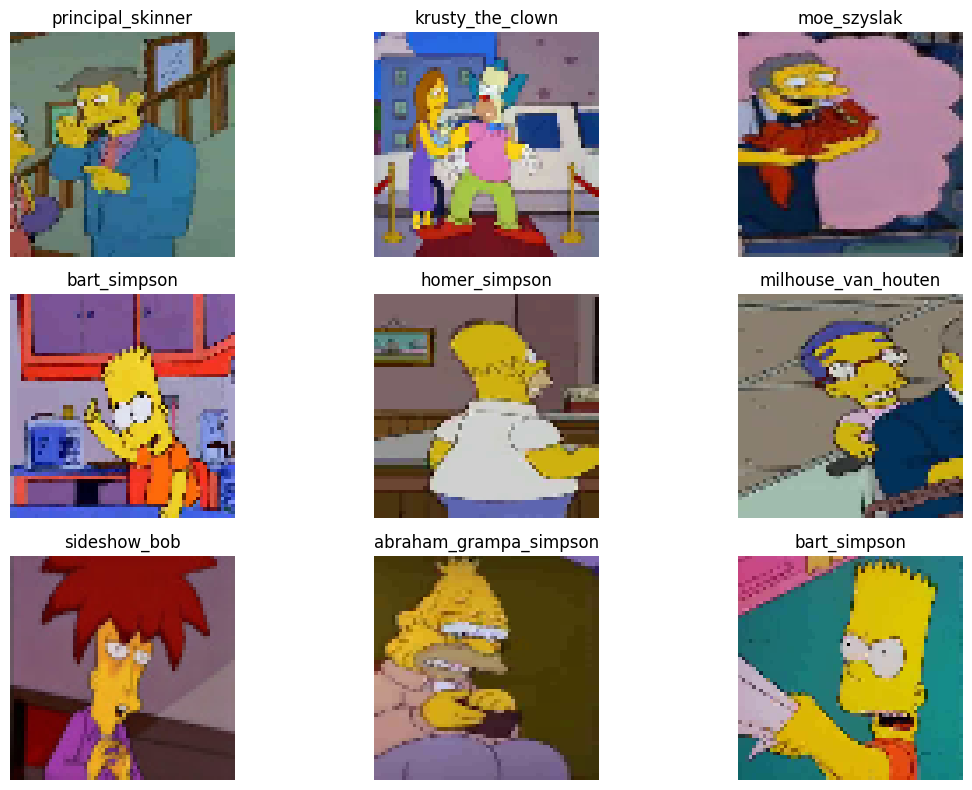

In [ ]:
# Crea una figura para visualizar imágenes
plt.figure(figsize=(12,8))

# Recorre las primeras 9 imágenes del dataset
for i in range(9):

    # Organiza las imágenes en una cuadrículas 3x3
    plt.subplot(3,3,i+1)

    # Convierte la imagen de BGR a RGB y la muestra
    plt.imshow(cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB))

    # Obtiene la etiqueta correspondiente
    label = y[i]

    # Muestra el nombre del personaje
    plt.title(MAP_CHARACTERS[label])

    # Oculta los ejes de la imagen
    plt.axis("off")

# Ajusta automáticamente los espacios
plt.tight_layout()

# Muestra la visualización final
plt.show()

**CONCLUSIONES:**

1. Se observan diferencias de poses, ángulos, iluminación, expresiones faciales y fondos. Por ejemplo, Lisa aparece de perfil, mientras que Homer se muestra en dos escenarios distintos y Milhouse cambia de posición y tamaño entre imágenes. Esto implica que la red no puede limitarse a memorizar imágenes específicas, sino que debe aprender patrones generales que permitan reconocer a cada personaje en diferentes contextos.

2. También se identificaron diferencias de escala y encuadre. Algunos personajes ocupan casi toda la imagen, mientras que otros aparecen más alejados o parcialmente visibles. Por ejemplo, Lisa aparece en un primer plano donde su rostro ocupa gran parte del recuadro, mientras que Milhouse y Sideshow Bob aparecen en planos más amplios mostrando parte del cuerpo y la vestimenta. Esta variabilidad aumenta la complejidad del problema, ya que la red debe reconocer personajes aunque cambien de tamaño, posición o no se encuentren centrados en la imagen.

3. Otro aspecto relevante es la similitud visual entre algunos personajes. Muchos comparten colores, estilos de dibujo y rasgos faciales similares. Esto obliga a la red a aprender atributos más específicos, como formas de ojos, peinados, accesorios, contornos y proporciones faciales, evitando depender únicamente del color para clasificar correctamente.

4. Además, el dataset contiene ruido visual. Varias imágenes presentan fondos complejos, objetos adicionales e incluso otros personajes dentro de la escena. Por ejemplo, Ned Flanders en la taberna de Moe o Homer conduciendo, el fondo incorpora múltiples elementos que no aportan directamente a la clasificación. A diferencia de datasets más simples como MNIST, donde el fondo es uniforme, aquí la red debe aprender a distinguir el personaje principal del resto de la escena.

5. Por otra parte, todas las imágenes fueron redimensionadas a 64x64 píxeles. Sin embargo, esta reducción también disminuye el nivel de detalle visual, dificultando la diferenciación entre personajes similares. Debido a esto, la red deberá extraer características relevantes incluso en imágenes de baja resolución.

### **5.3. Distribución de clases**

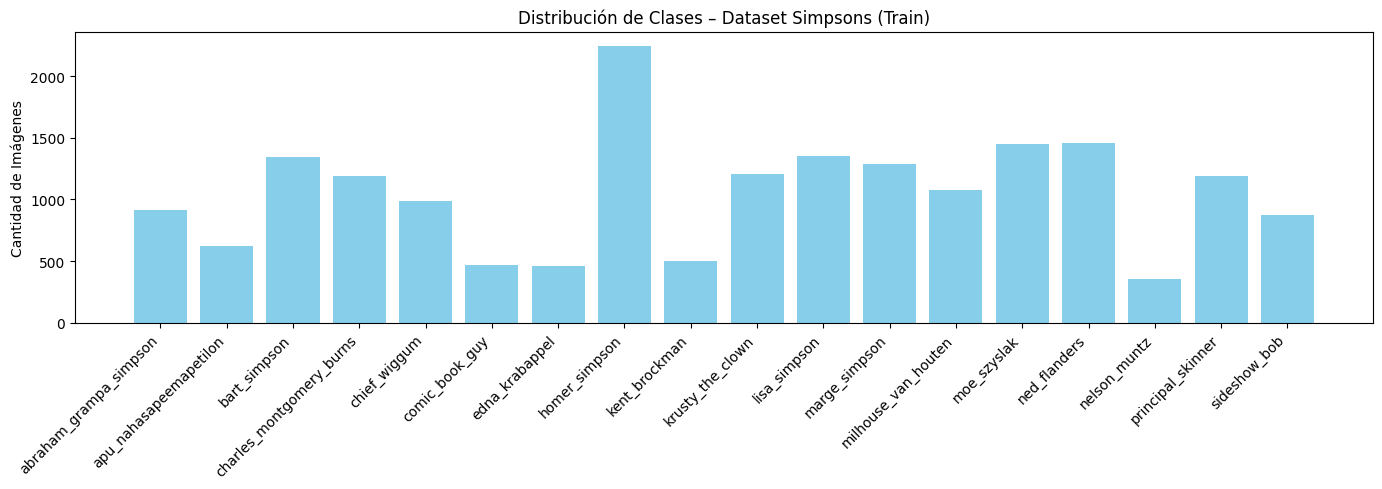

In [ ]:
# Cuenta cuántas imágenes existen por cada clase
unique, counts = np.unique(y, return_counts=True)

# Obtiene el nombre de cada personaje
labels = [MAP_CHARACTERS[i] for i in unique]

# Crea la figura del gráfico
plt.figure(figsize=(14, 5))

# Genera el gráfico de barras
plt.bar(labels, counts, color='skyblue')
# Título del gráfico
plt.title("Distribución de Clases – Dataset Simpsons (Train)")
# Nombre del eje
plt.ylabel("Cantidad de Imágenes")
# Rota las etiquetas
plt.xticks(rotation=45, ha='right')
# Ajusta los espacios
plt.tight_layout()
# Muestra el gráfico
plt.show()

**CONCLUSIONES:** En este gráfico, se puede visualizar la cantidad de imágenes que contiene cada variable o clase (personaje) en el set de datos de entrenamiento. Podemos observar que la clase con más imágenes es la de "Homer_Simpson" con una cantidad de 2.200. Por otro lado, debemos tener en cuenta que hay varias clases que tienen una cantidad de imágenes que están entre las 1.000 y las 1.500, como las de “Bart, Lisa, Marge, Moe, Ned Flanders y Mr.Burns”, y hay otro conjunto de clases que no tienen más de 500 imágenes, como por ejemplo “Edna Krabapple” o “Kent Brockman”.

Esto podría afectar bastante al modelo, ya que si los datos se dejan así como están (desbalanceados), el modelo podría ver a Homero casi siete veces más que a Nelson. Gracias al sesgo por ser la clase mayoritaria, la red aprenderá extremadamente bien las características visuales de Homero, pero podría predecir “Homero” cuando tenga dudas con otros personajes (Falsos positivos), si este modelo pasa a evaluarse usando el Accuracy global, podría dar valores altos solamente porque acierta casi siempre con la clase mayoritaria “Homero”, y el resto de personajes que tienen una cantidad de imágenes que rondan las 1.000 y las 1.500 ocultando el pésimo rendimiento que tendrá al clasificar a los personajes de las clases minoritarias, como por ejemplo “Nelson” o “Comic Book Guy”. Por otro lado, las clases que tienen menos de 500 imágenes corren riesgo de sufrir sobreajuste, ya que el modelo tiene pocas variantes visuales(Fondos, Ángulos, expresiones) para aprender a generalizar correctamente a esos personajes.


## **6. PREPROCESAMIENTO**

### **6.1. División entrenamiento-validación**

El objetivo de esta sección es dividir el conjunto de datos bajo una regla fundamental: no hacer trampa. De las casi 19.000 imágenes disponibles en total, el código reserva el 80% (15.193 muestras) para que la red neuronal "estudie", conformando así el conjunto de entrenamiento. El 20% restante (3.799 imágenes) se reguarda de forma independiente como el grupo de prueba. El modelo jamás tendrá acceso a este último bloque durante sus tutorías, ya que su único propósito será actuar como un simulacro sorpresa al final de cada época, de este modo, se evalúa si la arquitectura realmente aprendió a reconocer características visuales de la serie o si simplemente memorizó los ejemplos.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    # Imágenes del dataset
    X,
    # Etiquetas numéricas
    y,
    # Reserva el 20% para validación
    test_size=0.20,
    # Fija una semilla
    random_state=42,
    # Mantiene proporción de clase
    stratify=y
)

print(f"------------------------------------------")
print(f"Entrenamiento: {X_train.shape[0]} imágenes")
print(f"------------------------------------------")
print(f"Validación: {X_val.shape[0]} imágenes")
print(f"------------------------------------------")

------------------------------------------
Entrenamiento: 15193 imágenes
------------------------------------------
Validación: 3799 imágenes
------------------------------------------


### **6.2. Balance de clases y Data Augmentation**

**Identificación de desbalance y definición del objetivo**

En esta sección se analiza la distribución de las categorías dentro del conjunto de entrenamiento (y_train) con el objetivo de identificar el grado de desbalance existente. Mediante la función "np.unique", se extraen tanto las etiquetas de los personajes como sus frecuencias absolutas. A partir de estos datos, se toma como referencia la clase mayoritaria, asignando su volumen máximo de muestras a la variable "target_count". Este valor se establece como la meta estandarizada para el resto de las clases, con el fin de dar uniformidad al dataset. Finalmente, se define una semilla "SEED=42" para garantizar la reproducibilidad de los resultados, garantizando que la generación de datos sintéticos sea idéntica en ejecución.

In [ ]:
# Semilla fija
SEED = 42
# Fija la semilla en Numpy
np.random.seed(SEED)
# Fija la semilla en TensorFlow
tf.random.set_seed(SEED)

# Obtiene las clases y la cantidad de imágenes por clase en Train
unique, counts = np.unique(y_train, return_counts=True)
# Define como objetivo la cantidad de imágenes de la clase mayoritaria
target_count = counts.max()

print(f"------------------------------------------------------------")
print(f"Clase mayoritaria: {MAP_CHARACTERS[unique[counts.argmax()]]}"f" con {target_count} imágenes")
print(f"------------------------------------------------------------")
print(f"Objetivo por clase: {target_count} imágenes")
print(f"------------------------------------------------------------")

------------------------------------------------------------
Clase mayoritaria: homer_simpson con 1797 imágenes
------------------------------------------------------------
Objetivo por clase: 1797 imágenes
------------------------------------------------------------


**Generación de muestras sintéticas mediante Data Augmentation**

En esta sección se implementa la estrategia de balanceo mediante aumentación de datos (Data Augmentation) utilizando la clase ImageDataGenerator de Keras. Para ello, se configuran diversas transformaciones geométricas y fotométricas, tales como rotación, traslación, zoom, inversión horizontal y variaciones de brillo, que permiten generar nuevas imágenes sintéticas realistas a partir de las existentes. El procedimiento recorre iterativamente cada categoría del conjunto de entrenamiento, calculando en la variable “n_faltantes” el déficit exacto de muestras en relación con el objetivo estandarizado “tarjet_count”.

In [ ]:
# Generador encargado de crear imágenes sintéticas mediante transformaciones
augmenter = ImageDataGenerator(
    # Aplica pequeñas rotaciones aleatorias
    rotation_range=12,

    # Desplaza la imagen horizontalmente
    width_shift_range=0.08,

    # Desplaza la imagen verticalmente
    height_shift_range=0.08,

    # Aplica zoom aleatorio
    zoom_range=0.10,

    # Invierte horizontalmente la imagen
    horizontal_flip=True,

    # Cambia ligeramente el brillo
    brightness_range=(0.85, 1.15),

    # Rellena espacios vacíos generados por transformaciones
    fill_mode="nearest",
)

# Lista donde se almacenarán las imágenes sintéticas
X_extra = []
# Lista donde se almacenarán las etiquetas sintéticas
y_extra = []

# Recorre cada clase del dataset
for label in unique:
    # Busca las posiciones que pertenecen a esta clase
    idx_class = np.where(y_train == label)[0]

    # Cuenta cuántas imágenes tiene actualmente la clase
    n_actual = len(idx_class)

    # Calcula cuántas imágenes faltan para igualar la clase mayoritaria
    n_faltantes = target_count - n_actual

    # Si la clase ya está balanceada no genera nuevas imágenes
    if n_faltantes <= 0:
        print(f"{MAP_CHARACTERS[label]:30s} → ya tiene {n_actual} (OK)")
        continue

    print(f"{MAP_CHARACTERS[label]:30s} → generando {n_faltantes} muestras"f" (tiene {n_actual})")

    # Obtiene las imágenes originales de la clase actual
    X_clase = X_train[idx_class]

    # Generador que produce imágenes modificadas automáticamente
    flow = augmenter.flow(
        X_clase,
        # Tamaño máximo del lote de imágenes generadas
        batch_size=min(32, n_actual),
        shuffle=True,
        seed=SEED,
    )

    # Contador de imágenes sintéticas generadas
    generadas = 0

    # Repite el proceso hasta completas las imágenes faltantes
    while generadas < n_faltantes:
        # Obtiene un lote de imágenes aumentadas
        batch = next(flow)

        # Convierte las imágenes al formato entero de píxeles
        batch = batch.astype(np.uint8)

        # Calcula cuántas imágenes tomar sin exceder el objetivo
        n_tomar = min(len(batch), n_faltantes - generadas)

        # Guarda las imágenes generadas
        X_extra.append(batch[:n_tomar])

        # Guarda las etiquetas correspondientes
        y_extra.append(np.full(n_tomar, label, dtype=y_train.dtype))

        # Actualiza el contador de imágenes generadas
        generadas += n_tomar

# Une todas las imágenes y etiquetas sintéticas en un único arreglo
X_extra = np.concatenate(X_extra, axis=0)
y_extra = np.concatenate(y_extra, axis=0)

# Agrega las imágenes y etiquetas sintéticas al conjunto de Train
X_train = np.concatenate([X_train, X_extra], axis=0)
y_train = np.concatenate([y_train, y_extra], axis=0)

# Genera un orden aleatorio para mezclar el dataset balanceado
perm = np.random.permutation(len(X_train))

# Mezcla imágenes y etiquetas
X_train, y_train = X_train[perm], y_train[perm]

abraham_grampa_simpson         → generando 1067 muestras (tiene 730)
apu_nahasapeemapetilon         → generando 1299 muestras (tiene 498)
bart_simpson                   → generando 723 muestras (tiene 1074)
charles_montgomery_burns       → generando 843 muestras (tiene 954)
chief_wiggum                   → generando 1008 muestras (tiene 789)
comic_book_guy                 → generando 1422 muestras (tiene 375)
edna_krabappel                 → generando 1431 muestras (tiene 366)
homer_simpson                  → ya tiene 1797 (OK)
kent_brockman                  → generando 1399 muestras (tiene 398)
krusty_the_clown               → generando 832 muestras (tiene 965)
lisa_simpson                   → generando 714 muestras (tiene 1083)
marge_simpson                  → generando 764 muestras (tiene 1033)
milhouse_van_houten            → generando 934 muestras (tiene 863)
moe_szyslak                    → generando 635 muestras (tiene 1162)
ned_flanders                   → generando 634 muestra

**CONCLUSIÓN:** Las muestras sintéticas generadas se almacenan temporalmente en los arreglos “X_extra” e “y_extra” para luego fusionarse con el conjunto de entrenamiento original. Tras la concatenación, se realiza una mezcla aleatoria del conjunto para evitar sesgos en el orden de los datos. En la Salida se observa con claridad cómo las clases minoritarias, como “nelson_muntz” o “edna_krabappel” demandan un volumen significativamente mayor de muestras generadas para alcanzar el equilibrio, logrando nivelar con éxito el terreno de aprendizaje.

**Verificación del balance de clases**

Posteriormente, se valida el resultado del proceso de sobremuestreo recalculando la distribución de frecuencias sobre el conjunto de entrenamiento actualizado.

In [ ]:
# Verifica nuevamente la distribución de clases
unique, counts = np.unique(y_train, return_counts=True)
print(f"---------------------------------------------")
print(f"Dataset balanceado: {len(X_train)} imágenes totales")
print(f"---------------------------------------------")
print(f"Imágenes por clase: {counts.min()} – {counts.max()}")
print(f"---------------------------------------------")

---------------------------------------------
Dataset balanceado: 32346 imágenes totales
---------------------------------------------
Imágenes por clase: 1797 – 1797
---------------------------------------------


**CONCLUSIÓN:** La salida del código confirma el éxito del procedimiento, todas las categorías alcanzaron el mismo volumen representativo, estabilizándose en 1.797 imágenes por clase. Como consecuencia de esta nivelación, el tamaño del conjunto de entrenamiento se expandió a un total de 32.346 muestras.


### **6.3. Verificación del balance de clases tras Data Augmentation**

Para consolidar de forma gráfica la efectividad del proceso de sobremuestreo, se genera una visualización de la distribución final de las categorías en el conjunto de entrenamiento actualizado. El objetivo es contrastar el volumen de cada clase frente al umbral preestablecido.

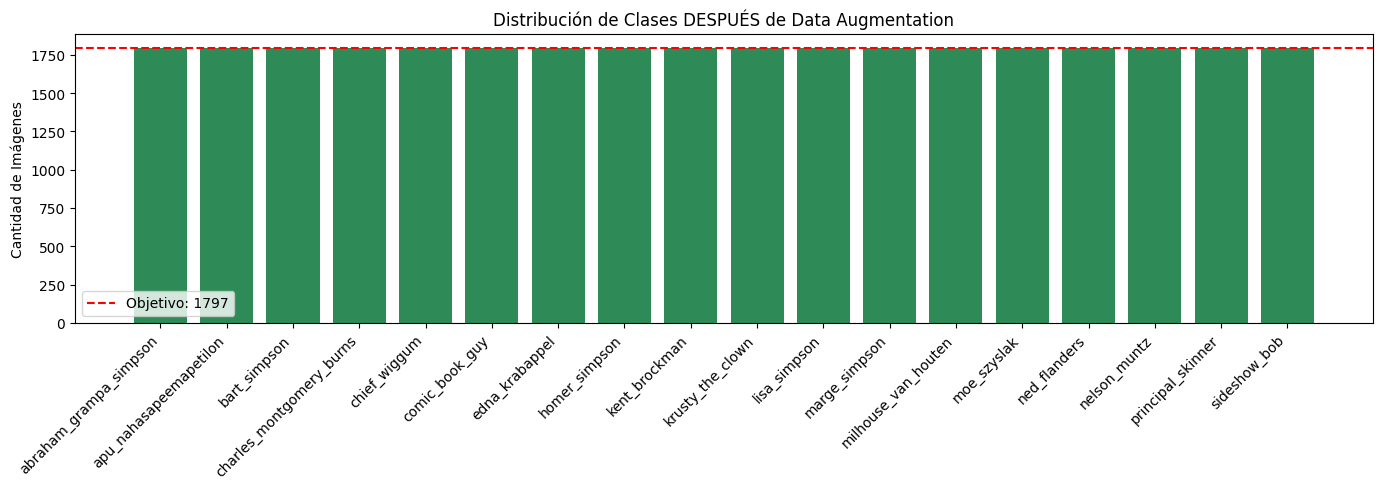

In [ ]:
# Crear figura
plt.figure(figsize=(14, 5))

# Genera el gráfico de barras
plt.bar(
    # Nombres de los personajes
    [MAP_CHARACTERS[i] for i in unique],
    # Cantidad de imágenes por clase
    counts,
    color="seagreen",
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Clases DESPUÉS de Data Augmentation")
plt.ylabel("Cantidad de Imágenes")

# Dibuja una línea horizontal
plt.axhline(
    target_count,
    color="red",
    linestyle="--",
    label=f"Objetivo: {target_count}")

# Muestra la leyenda
plt.legend()
# Ajusta los espacios del gráfico
plt.tight_layout()
# Muestra el gráfico
plt.show()

**CONCLUSIÓN:** A través del gráfico, se ve que cada una de las categorías alcanza con precisión el valor objetivo de 1.797 muestras. La línea horizontal discontinua funciona como una guía de referencia que convalida el éxito, evidenciando que todas las barras se nivelaron de manera idéntica. Esta distribución uniforme mitiga el sesgo que el desbalance original habría provocado en la CNN, forzándola a otorgar la misma importancia a cada personaje y optimizando su capacidad de generalización ante imágenes completamente nuevas.


### **6.4. Comparación de Muestras Originales vs Sintéticas**

En esta sección se implementa una herramienta de inspección visual con el propósito de contrastar las imágenes originales frente a sus respectivas variantes artificiales. Esta demostración permite validar el comportamiento del generador y entender la naturaleza de los datos que alimentarán a la CNN. Se ha seleccionado específicamente la clase 6 (Edna Krabappel) por ser una de las categorías minoritarias que requirió un mayor volumen de sobremuestreo sintético, permitiendo evaluar cómo la técnica de aumentación expande el repertorio de aprendizaje del modelo.

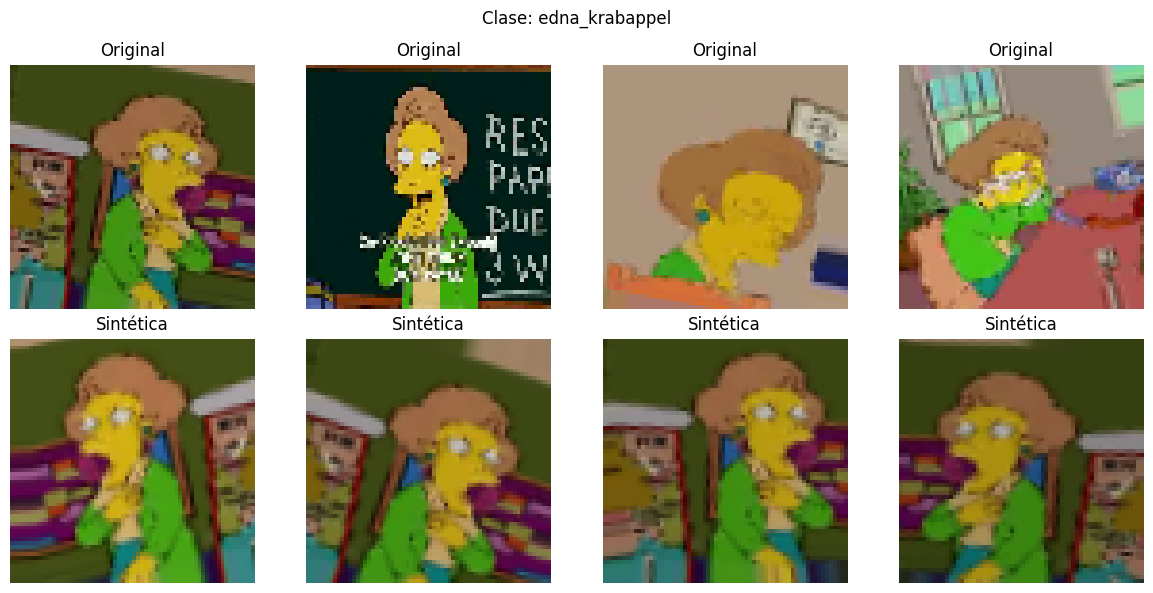

In [ ]:
# Selecciona una clase con pocas imágenes
clase_demo = 6
# Obtiene las posiciones de algunas imagenes originales de esa clase
idx_orig = np.where(y_train == clase_demo)[0][:4]

# Crea una figura
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
# Muestra 4 imágenes originales
for i, idx in enumerate(idx_orig):

    # Convierte la imagen de BGR a RGB y la muestra
    axs[0, i].imshow(cv2.cvtColor(X_train[idx], cv2.COLOR_BGR2RGB))
    axs[0, i].set_title("Original")
    axs[0, i].axis("off")

# Selecciona una imagen para generar variaciones sintéticas
sample = X_train[idx_orig[0]:idx_orig[0]+1]

# Generador encargado de crear nuevas versiones de la imagen
flow = augmenter.flow(sample, batch_size=1, seed=SEED)

# Genera y muestra 4 imágenes sintéticas
for i in range(4):
    # Obtiene una imagen aumentada
    aug = next(flow)[0].astype(np.uint8)
    axs[1, i].imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
    axs[1, i].set_title("Sintética")
    axs[1, i].axis("off")

plt.suptitle(f"Clase: {MAP_CHARACTERS[clase_demo]}", fontsize=12)
plt.tight_layout()
# Muestra la figura
plt.show()

**CONCLUSIÓN:** A nivel específico, lo que hace cada parte del código es con clase_demo=6, definir exactamente qué personaje se va a analizar, ayudando a filtrar el conjunto de datos para aislar solo las fotos de Edna Krabappel como ejemplo. Luego, con figsize=(12, 6) configura las dimensiones del lienzo del gráfico, es decir, el ancho y el largo, lo que asegura que las imagenes se rendericen con buen tamaño y no se vean deformes o aplastadas. Con cv2.COLOR_BGR2RGB corregimos el formato de color. OpenCV lee las imágenes en formato BGR (azul, verde, rojo) es decir, al reves, pero la librería de gráficos las necesita en RGB. Esto evita que los personajes salgan con la piel azul. Básicamente estamos haciendo que los personajes pasen a RGB y no se mantengan en BGR. Con batch_size=1 le indicamos al generador que tome y devuelva exactamente una sola imagen alterada por cada paso del ciclo. Con seed=SEED hacemos que los giros o zoom sean siempre los mismos, esto lo hacemos para garantizar que las imágenes sintéticas generadas sean exactamente las mismas cada vez que corra la celda. Finalmente, con fontsize=12 se determina el tamaño de la fuente del título general del gráfico para que sea legible en la presentación.

### **6.5. Normalización de los datos**

En esta etapa se realiza la normalización de las imágenes. Originalmente, los píxeles poseen valores enteros entre 0 y 255, donde 0 representa ausencia de color y 255 la máxima intensidad. Al dividir cada píxel por 255, los valores quedan escalados en un rango entre 0 y 1. Esta transformación facilita el aprendizaje de la CNN, mejorando la estabilidad numérica y permitiendo un entrenamiento más eficiente del modelo.

In [ ]:
# Normalizar imágenes de entrenamiento
X_train = X_train / 255.0

# Normalizar imágenes de validación
X_val  = X_val / 255.0

# Normalizar imágenes de prueba
X_test  = X_t / 255.0

**JUSTIFICACIÓN:**

- Este proceso facilita el trabajo de la red, ya que resulta más eficiente procesar valores pequeños y escalados que números grandes. Además, muchas funciones de activación, como ReLU o sigmoide, presentan un mejor comportamiento cuando los datos se encuentran en rangos cercanos a 0.

- La normalización también mejora el entrenamiento del modelo. La red aprende ajustando sus parámetros mediante pequeños cambios llamados gradientes. Si los valores de entrada son demasiado grandes, estos ajustes pueden volverse inestables o bruscos, dificultando el aprendizaje.

- Por ello, al llevar todos los píxeles a un mismo rango de valores, la CNN puede entrenarse de forma más estable y eficiente, enfocándose en aprender patrones, formas y características visuales relevantes de las imágenes, en lugar de lidiar con diferencias de escala entre los datos.

### **6.6. Codificación de etiquetas**

El objetivo de esta etapa final es transformar las etiquetas categóricas mediante la técnica de One-Hot Encoding. Hasta este punto, las clases que identifican a los integrantes de la serie se representan con números enteros del 0 al 17 dentro de los arreglos y_train e y_t. Si se mantuviera este formato secuencial, donde la etiqueta de Bart Simpson es simplemente 2, la red neuronal podría asumir erróneamente relaciones de orden, jerarquía o magnitud, por ejemplo, interpretar que el elemento 4 (Chief Wiggum) vale el doble que el 2 (Bart), o que Apu (1) y Bart (2) pueden sumarse para dar como resultado a Burns (3). Para neutralizar este sesgo, este método actúa como un "Interruptor de luces", convierte cada índice entero en un vector de 18 posiciones donde todas se apagan con un cero, excepto la casilla del personaje correspondiente, la cual se enciende exclusivamente con un uno.

In [ ]:
# Cantidad total de clases del dataset
NUM_CLASSES = len(MAP_CHARACTERS)

# Convierte etiquetas de entrenamiento a One-Hot Encoding
Y_train = keras.utils.to_categorical(y_train, NUM_CLASSES)

# Convierte etiquetas de validación a One-Hot Encoding
Y_val  = keras.utils.to_categorical(y_val, NUM_CLASSES)

# Convierte etiquetas del conjunto de prueba
Y_test  = keras.utils.to_categorical(y_t, NUM_CLASSES)

## **7. MODELOS CNN**

### **7.1. Configuración experimental**

Aunque la semilla de reproducibilidad (SEED=42) ya fue utilizada durante el preprocesamiento para mantener la consistencia en la generación de imágenes sintéticas, en esta nueva se vuelve a definir para asegurar que todos los modelos comiencen bajo las mismas condiciones. Aquí el uso de la semilla ya no afecta la creación de imágenes, sino procesos internos del entrenamiento, como la inicialización de los pesos de la red y el funcionamiento de técnicas como Dropout. Al fijar nuevamente las semillas de Numpy y TensorFlow, se garantiza que las arquitecturas evaluadas puedan compararse de manera justa y reproducible, reduciendo variaciones causadas por el azar.

In [ ]:
# Semilla fija para reproducibilidad
SEED = 42

# Fija semilla en Numpy
np.random.seed(SEED)

# Fija semilla en TensorFlow
tf.random.set_seed(SEED)

### **7.2. Modelo 1 - CNN Base**

### **7.2.1. Arquitectura del modelo**

La arquitectura de una red neuronal define cómo se organizan sus capas y cómo la información avanza entre ellas. En este caso, el modelo recibe una imagen y la procesa paso a paso hasta transformarla en una predicción final sobre qué personaje de Los Simpsons aparece en ella. De forma general, la red primero identifica características simples de la imagen, luego reduce la información menos importante y finalmente utiliza lo aprendido para decidir a qué clase pertenece la imagen.

In [ ]:
# Crea una red neuronal secuencial
model_1 = keras.Sequential([

    # Extrae características básicas de la imagen
    Conv2D(32, (3,3),
           activation='relu',
           input_shape=(64,64,3)),

    # Reduce el tamaño de los mapas de características
    MaxPooling2D((2,2)),

    # Convierte la información en un vector
    Flatten(),

    # Capa densa para aprender patrones complejos
    Dense(32, activation='relu'),

    # Capa de salida con una neurona por clase
    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **7.2.2. Compilación del modelo**

Una vez definida la arquitectura de la CNN, el siguiente paso es realizar la compilación del modelo. Esta etapa configura los elementos que permitirán a la red aprender durante el entrenamiento. Primero, se utiliza el optimizador adam, encargado de ajustar automáticamente los pesos de la red para mejorar sus predicciones en cada iteración. Luego, se define la función de pérdida categorical_crossentropy, utilizada para medir qué tan diferente es la predicción del modelo respecto a la clase correcta de cada personaje. Finalmente, se incorpora la métrica accuracy, la cual permite observar de forma simple el porcentaje de aciertos obtenido por la red durante el entrenamiento.

In [ ]:
model_1.compile(
    # Optimizador encargado de ajustar los pesos de la red
    optimizer='adam',

    # Función de pérdida para clasificación multiclase
    loss='categorical_crossentropy',

    # Métrica de evaluación de rendimiento
    metrics=['accuracy']
)

### **7.2.3. Entrenamiento del modelo**

Una vez definida y compilada la arquitectura CNN, se inicia la etapa de entrenamiento del modelo mediante el método .fit(). En esta fase, la red neuronal comienza a aprender a partir de las imágenes del conjunto de entrenamiento. El entrenamiento se realiza en grupos de 64 imágenes y se repite durante 20 épocas, permitiendo que el modelo mejore progresivamente sus predicciones. Además, en cada época los datos se reorganizan de forma aleatoria para evitar que el aprendizaje dependa del orden de las imágenes. Al finalizar cada época, el modelo también es evaluado con el conjunto de validación. Esto permite observar cómo está funcionando la red con datos que no fueron utilizados directamente durante el aprendizaje. Como resultado, se genera el objeto history_model_1, el cual almacena métricas como la pérdida y la precisión obtenidas durante el entrenamiento y la validación. Esta información será utilizada posteriormente para analizar el comportamiento y rendimiento del modelo.

In [ ]:
history_model_1 = model_1.fit(
    # Imágenes de entrenamiento
    X_train,

    # Etiquetas codificadas
    Y_train,

    # Datos utilizados para validación
    validation_data=(X_val, Y_val),

    # Mezcla aleatoriamente los datos en cada época
    shuffle=True,

    # Número total de épocas de entrenamiento
    epochs=20,

    # Cantidad de imágenes procesadas por lote
    batch_size=64
)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2773 - loss: 2.3519 - val_accuracy: 0.3935 - val_loss: 2.0065
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4749 - loss: 1.7747 - val_accuracy: 0.4312 - val_loss: 1.9054
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5303 - loss: 1.5783 - val_accuracy: 0.4733 - val_loss: 1.8036
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5748 - loss: 1.4308 - val_accuracy: 0.4920 - val_loss: 1.7488
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6065 - loss: 1.3133 - val_accuracy: 0.5041 - val_loss: 1.7138
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6378 - loss: 1.1994 - val_accuracy: 0.5236 - val_loss: 1.6837
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6667 - loss: 1.0965 - val_accuracy: 0.5259 - val_loss: 1.7086
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6923 - loss: 1.0097 - val_accuracy: 

**ANÁLISIS:**

1. **Posible subajuste (underfitting):** Si tanto accuracy como val_acurracy se mantienen en valores bajos, significa que el modelo no está aprendiendo correctamente patrones de las imágenes. Esto ocurre porque una sola capa convolucional no es suficiente para reconocer detalles más complejos de los 18 personajes, como formas del rostro, peinados o accesorios.

2. **Posible sobreajuste (overfitting):** Si el accuracy de entrenamiento aumenta mucho, pero el val_acurracy se mantiene bajo o comienza a empeorar, significa que el modelo está aprendiendo demasiado las imágenes de entrenamiento y tiene dificultades para reconocer imágenes nuevas. En otras palabras, memoriza los datos en lugar de aprender características generales.

### **7.2.4. Evaluación del modelo**

El propósito de esta subsección es realizar la evaluación final del modelo utilizando el conjunto de prueba. Esta etapa es importante porque permite comprobar cómo se comporta la CNN con imágenes que nunca vio durante el entrenamiento, ayudando a medir su capacidad real para reconocer nuevos datos. Mediante el método .evaluate(), se obtiene la pérdida y precisión final del modelo. Luego, se analiza el rendimiento de forma más detallada para cada uno de los 18 personajes del dataset. Este análisis permite identificar en qué personajes el modelo obtiene mejores resultados y en cuáles presenta más errores o confusiones.

In [ ]:
loss, acc = model_1.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")

# Genera predicciones del modelo
y_pred = np.argmax(model_1.predict(X_test), axis=1)
y_true = np.argmax(Y_test, axis=1)

# Muestra métricas de clasificación por clase
print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(MAP_CHARACTERS.values())
      )
    )

Accuracy: 79.44%  |  Loss: 0.8317
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.78      0.73      0.75        48
  apu_nahasapeemapetilon       0.88      0.92      0.90        50
            bart_simpson       0.62      0.80      0.70        50
charles_montgomery_burns       0.67      0.65      0.66        48
            chief_wiggum       0.93      0.84      0.88        50
          comic_book_guy       0.82      0.94      0.88        49
          edna_krabappel       0.89      0.84      0.87        50
           homer_simpson       0.84      0.76      0.80        50
           kent_brockman       0.95      0.80      0.87        50
        krusty_the_clown       1.00      0.68      0.81        50
            lisa_simpson       0.65      0.60      0.62        50
           marge_simpson       0.87      0.82      0.85        50
     milhouse_van_houten       0.70      0.92      0.80        49
 

Podemos ver que la exactitud(Accuracy) del modelo es de 37.19% esto nos está diciendo que el modelo solamente está acertando al personaje correcto aproximadamente 1 de cada 3 imágenes. Este rendimiento es bastante bajo para este modelo teniendo en cuenta que estamos dando solución a un problema de clasificación, podemos ver que el modelo tiene unas clases las cuales se podrian decir que son las favoritas ya que tienen un rendimiento mucho mayor que el resto de clases, la clase de “Marge Simpson” es el personaje que el modelo mejor reconoce dando un F1-Score de (0.66) este es uno de los más altos, también tiene la precisión más alta con un (0.70) lo que significa que cuando el modelo dice que es marge suele acertar pero no siempre, los que siguen en la lista de favoritos son “Kent Brockman” y “Comic Book Guy” tienen un rendimiento(F1-Score) aceptable en comparación al resto de clases, el valor de “Kent Brockman” es de (0.57) y el valor de “Comic Book Guy” es de (0.54), por otro lado tenemos a las clases que el modelo les cuesta mucho reconocer, estos serían Nelson Muntz con un F1-Score de (0.03), Edna Krabappel con un F1-Score de (0.06) y Moe Szyslak con un F1-Score de (0.10), estos son casi indetectables para el modelo, en pocas palabras el modelo se vuelve “Ciego” cuando se trata de reconocer a estos personajes y para terminar tenemos una clase muy particular, se trata de la clase de el personaje “Apu” ya que tiene un  un recall de (0.94) y esto nos está diciendo que el modelo está encontrando casi el 100% de las imágenes reales de Apu pero debemos tener en cuenta que el precision es de un (0.36) esto es bastante bajo para tener un recall de (0.94), esto va a generar muchos falsos positivos (clasificara a otros personajes que no son “Apu” como si fueran “Apu”).

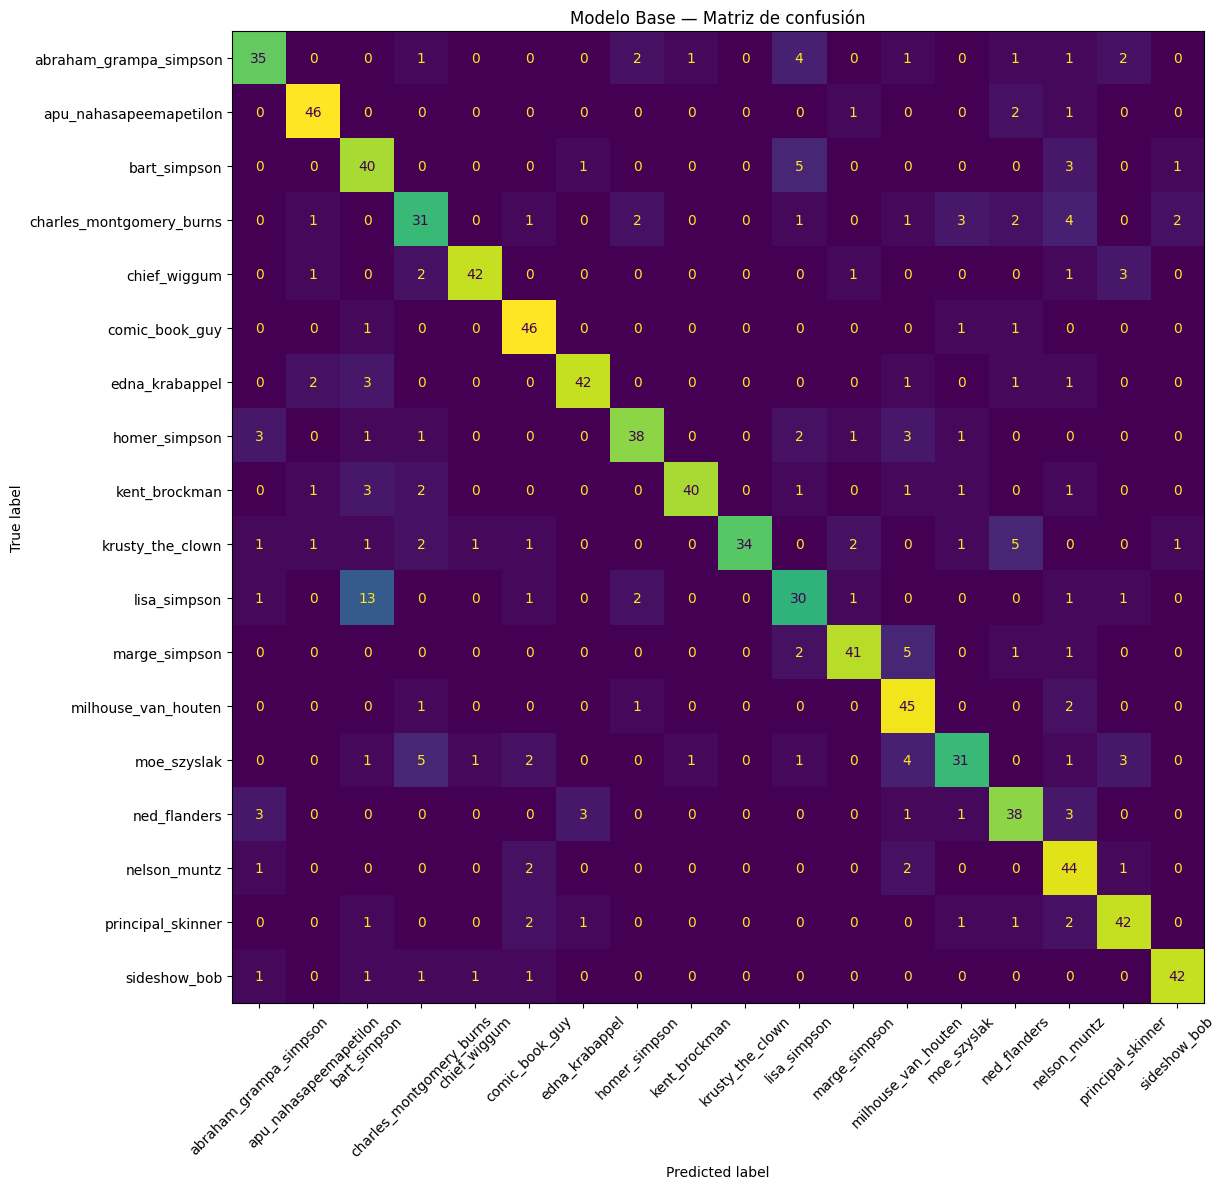

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(cm, display_labels=list(MAP_CHARACTERS.values()))

disp.plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.title('Modelo Base — Matriz de confusión')

plt.tight_layout()

plt.show()

> *Interpretación de matriz de confusión del modelo base:*

Se puede observar que en general el modelo predice bastante bien la mayoría de las clases logrando clasificar correctamente a unos 40 o mas ejemplo sobre un total de 50 por personaje en mucho de los casos, esto nos da una indicación que las clases están balanceadas, aquí nos estamos enfocando en los errores del modelo ya que el modelo no se equivoca al azar, se equivoca por las similitudes visuales que son muy importantes para una red neuronal haciendo que éste tienda a “alucinar” aquí uno de los problemas críticos  que podemos visualizar es que el modelo tiende a confundir mucho a la clase “Lisa” y a la clase “Bart” ya que si miramos la fila de “Lisa_Simpson” se ve que el modelo solo acertó 16 veces, pero clasificó a “Lisa” como “Bart” unas 24 veces, esto quiere decir que cuando el modelo ve a “Lisa” cree que es “Bart” la mayoría de las veces, esto puede que ocurra por que los dos ocupan la misma paleta de colores (amarillo, naranjo, rojo) y lo mas importante a tener en cuenta es la forma de la cabeza, por otro lado podemos ver que en la fila de la clase “Homer_simpson”, el modelo solo acierta 17 veces, aqui el modelo suele confundirse mucho al clasificar a “Homero” como “Abrahan_Simpson” (13 veces) ya que estos dos tienen una silueta en la cabeza bastante similar, la misma forma de la boca y en su gran parte de la contextura de su cuerpo, esto hace que la red neuronal este detectando la forma general pero esta fallando al momento de ver los detalles mas importantes para poder diferenciarlos como las arrugas de “Abraham_Simpson”(abuelo) o los dos pelos que tiene “Homero_Simpson”, podemos ver que a la clase de “Ned_Flanders” tiene 29 aciertos, pero fue clasificado como “Apu” 12 veces, probablemente la red debe estar confundiendo los rasgos faciales de estos ya que ambos tienen bigote color oscuro y cabellos peinados de forma similar asi que estos le probocan una confucion a la red al momento de reconocer quien es quien, tambien podemos observar que las clases de “Moe” es confundida con la clase de “Sr.Burns” en 10 ocasiones, esto puede que sea debido a las expresiones que ambos personajes tienen los cuales son muy similares y también por su contextura delgada, pero no todo es tan malo, también podemos ver que tenemos clases “estrella” ya que tienen una precisión bastante buena al momento de reconocerlas, La clase de “Edna Krabappel” tiene 43 aciertos, la clase de “Sideshow Bob” 43 aciertos y la clase de “Chief Wiggum” tiene 42 aciertos, esto puede ser por que estos personajes cuentan con características visuales  únicas que es difícil que la red neuronal confunda, ya que “Sideshow Bob” tiene un cabello gigante y rojo que ocupa la gran mayoría de la imagen, “Wiggum” tiene un cabello de color azul un uniforme de policia azul que esta dominando los pixeles de la imagen completa y “Edna” también tiene una silueta de cabello y colores de ropa muy particulares, asi que podemos decir que el modelo extrae caracteristicas dominantes con mucha facilidad.

> *Conclusion:*

El modelo ya aprendió a diferenciar formas muy generales y colores que dominan los pixeles de las imágenes, pero también está fallando en la extracción de características finas, como por ejemplo las diferencias de las puntas del cabello de la clase “Lisa” y la clase “Bart” o notar la edad en el rostro del abuelo en comparación de la de homero.

### **7.3. Modelo 2 - CNN con Mayor Profundidad**

### **7.3.1. Arquitectura del modelo**

Este segundo modelo es una versión más profunda que el modelo base.
A diferencia del primer modelo, se agregan más bloques convolucionales para que la red pueda aprender características más complejas de las imágenes. El primer bloque utiliza 64 filtros, orientados a detectar características simples como bordes, colores y texturas. Luego, los siguientes bloques utilizan 128 filtros, permitiendo capturar patrones más detallados e intermedios. Después de cada capa convolucional se aplica  MaxPooling2D para reducir el tamaño de los mapas de características y conservar la información más importante. Finalmente, se usa Flatten para transformar la información en un vector, una capa densa de 32 neuronas,para reducir el sobreajuste y una capa de salida con softmax para clasificar la imagen en una de las clases disponibles.

In [ ]:
modelo_2 = keras.Sequential([

    # Bloque 1 — igual que Modelo 1
    Conv2D(128, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    # Bloque 2 — única diferencia: más profundidad
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

modelo_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 62, 62, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 29, 29, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 845,746 (3.23 MB)

 Trainable params: 845,746 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

### **7.3.2. Entrenamiento del modelo**

En esta parte se entrena el modelo, tomando los parámetros fijos (epochs = 20, batch_size=64)

In [ ]:
history_model_2 = modelo_2.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    shuffle=True,
    verbose=1
)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.4437 - loss: 1.8728 - val_accuracy: 0.5262 - val_loss: 1.6029
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6315 - loss: 1.2612 - val_accuracy: 0.5970 - val_loss: 1.3784
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7034 - loss: 1.0134 - val_accuracy: 0.6294 - val_loss: 1.2868
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7475 - loss: 0.8566 - val_accuracy: 0.6423 - val_loss: 1.2731
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7801 - loss: 0.7412 - val_accuracy: 0.6533 - val_loss: 1.2828
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8073 - loss: 0.6452 - val_accuracy: 0.6804 - val_loss: 1.2421
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8272 - loss: 0.5686 - val_accuracy: 0.6904 - val_loss: 1.2655
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8408 - loss: 0.5152 - val_a

**CONCLUSIONES:** Durante el entrenamiento se observa que el modelo mejora de forma progresiva: el accuracy aumenta y la pérdida disminuye a medida que avanzan las épocas. Esto indica que la red está aprendiendo correctamente los patrones del conjunto de entrenamiento. Sin embargo, en validación el accuracy mejora al inicio y luego se estabiliza cerca del 70%, mientras que la pérdida comienza a aumentar después de la época 6. Esto evidencia cierto overfitting, ya que el modelo sigue mejorando en entrenamiento, pero no logra generalizar con la misma fuerza sobre datos nuevos.

### **7.3.3. Evaluación del modelo**

Accuracy: 89.21%  |  Loss: 0.6429
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.90      0.79      0.84        48
  apu_nahasapeemapetilon       0.94      0.94      0.94        50
            bart_simpson       0.78      0.70      0.74        50
charles_montgomery_burns       0.85      0.94      0.89        48
            chief_wiggum       0.98      0.94      0.96        50
          comic_book_guy       0.96      0.98      0.97        49
          edna_krabappel       0.84      0.94      0.89        50
           homer_simpson       0.77      0.82      0.80        50
           kent_brockman       0.86      0.96      0.91        50
        krusty_the_clown       0.94      0.92      0.93        50
            lisa_simpson       0.83      0.78      0.80        50
           marge_simpson       0.90      0.94      0.92        50
     milhouse_van_houten       0.95      0.86      0.90        49
 

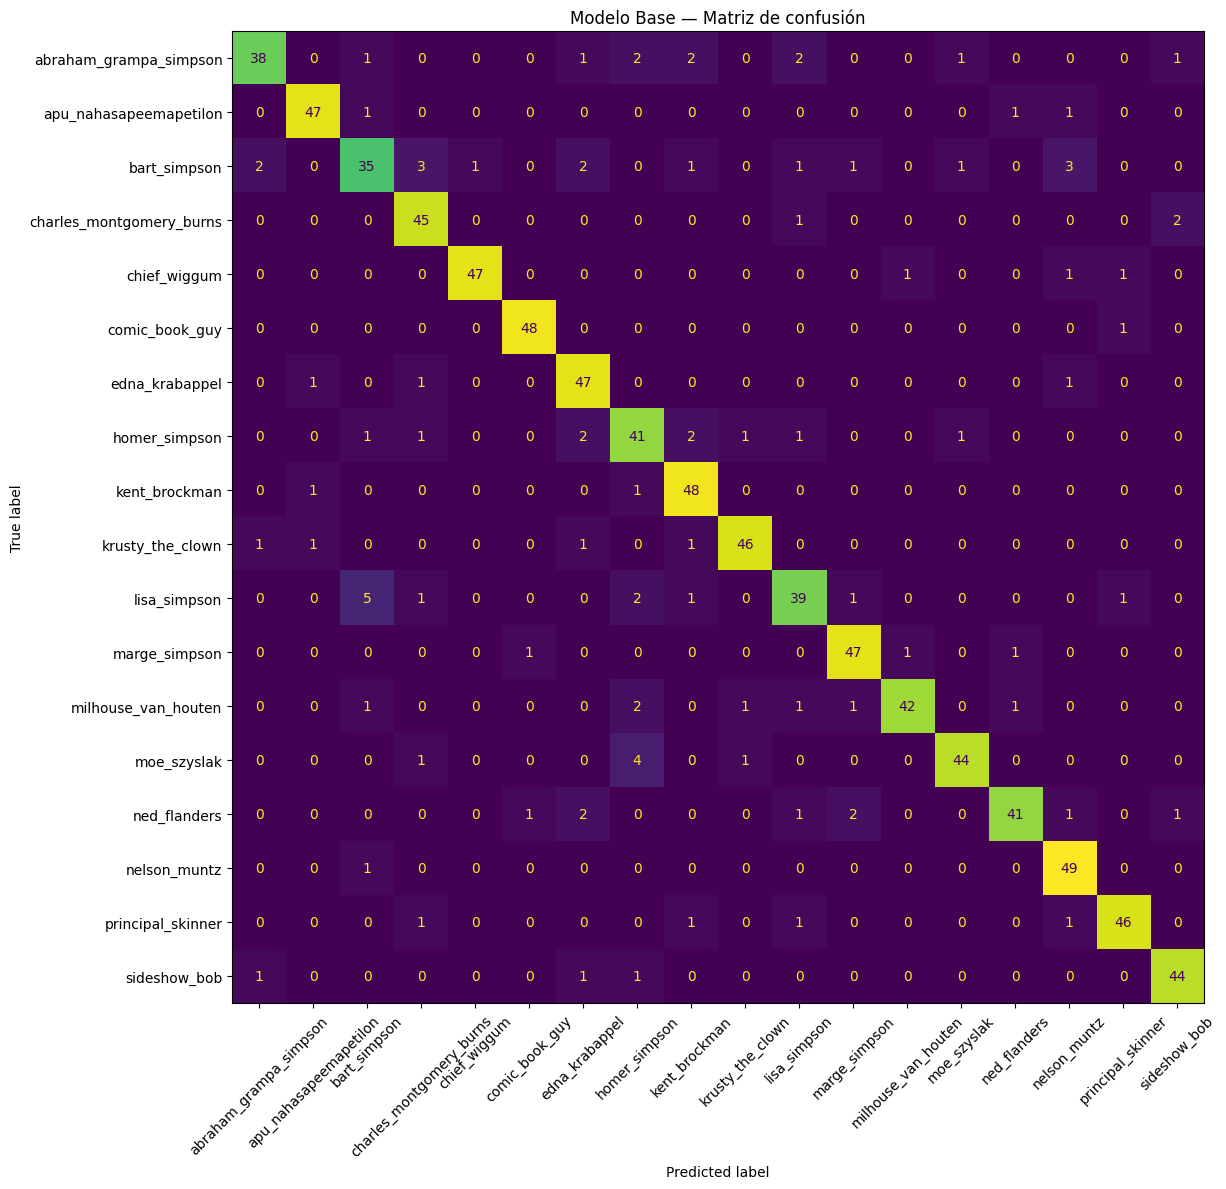

In [ ]:
loss, acc = modelo_2.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")

# Predicciones
y_pred = np.argmax(modelo_2.predict(X_test), axis=1)
y_true = np.argmax(Y_test, axis=1)

# Reporte por clase
print(classification_report(y_true, y_pred, target_names=list(MAP_CHARACTERS.values())))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=list(MAP_CHARACTERS.values()))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Modelo Base — Matriz de confusión')
plt.tight_layout()
plt.show()

**INTERPRETACIÓN DE MÉTRICAS:** El modelo presenta un buen rendimiento general, alcanzando un accuracy de 89.21% y un loss de 0.6429. Además, el F1-score promedio es de 0.89, lo que indica que logra clasificar correctamente la mayoría de las imágenes del conjunto de prueba.
Se puede observar que varias clases tienen un desempeño alto, como Comic Book Guy, Chief Wiggum, Apu, Krusty, Marge , Nelson , el director  Skinner y Sideshow Bob, con valores de F1-score cercanos o superiores a 0.90. Esto muestra que el modelo logra reconocer de buena forma las características visuales de estos personajes.
Sin embargo, todavía existen algunas clases con menor rendimiento en comparación con el resto. El caso más bajo es Bart, con un F1-score de 0.74. También se observan valores más bajos en Homero y Lisa , ambos con un F1-score de 0.80, aunque su desempeño mejoró respecto a resultados anteriores.
Estas diferencias pueden deberse a similitudes visuales entre algunos personajes, cambios de pose, expresiones, ropa o variaciones en las imágenes. Aun así, en términos generales, el modelo muestra una buena capacidad de clasificación y un rendimiento bastante equilibrado entre las clases.


**INTERPRETACIÓN DE LA MATRIZ:** La matriz de confusión permite observar visualmente en qué clases el modelo acierta y en cuáles se equivoca. En general, se aprecia una diagonal principal bastante marcada, lo que indica que el modelo clasifica correctamente la mayoría de las imágenes.
Hay clases con muy buen desempeño, como Comic Book Guy, Edna Krabappel, Kent Brockman, Nelson , Krusty, Marge y el director Skinner, donde la cantidad de aciertos es alta. Por ejemplo, Nelson alcanza 49/50 predicciones correctas, Comic Book Guy 48/49 y Kent Brockman 48/50, lo que coincide con sus buenos valores de recall en el reporte de clasificación.
También se observan algunas clases con más errores que el resto. El caso más notorio es Bart, con 35/50 aciertos, siendo una de las clases con menor rendimiento. Lisa  también presenta algunas confusiones, principalmente con Bart, aunque logra 39/50 aciertos.
En general, la matriz muestra que el modelo tiene un buen comportamiento, ya que la mayoría de las clases concentra sus predicciones en la diagonal principal. Aun así, todavía existen confusiones entre personajes visualmente parecidos o con variaciones de pose, ropa y expresión, especialmente en clases como Bart, Lisa y algunos casos puntuales de Abraham Simpson y Ned Flanders.

### **7.4. Comparación de Arquitecturas**

En este apartado se grafican el loss y accuracy de ambos modelos, y en base a el que tenga mejor comportamiento será el elegido como modelo base.

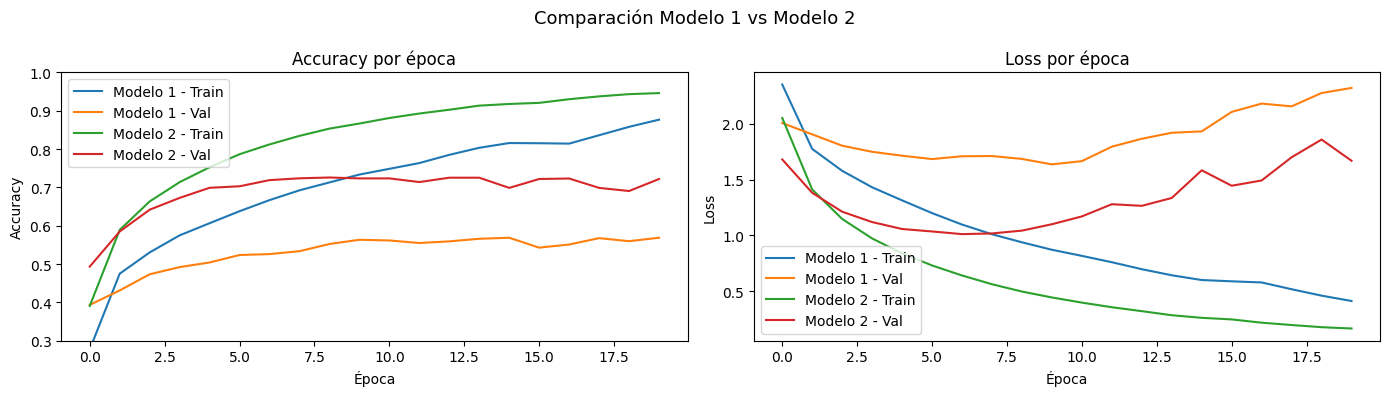

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history_model_1.history['accuracy'], label='Modelo 1 - Train')
axes[0].plot(history_model_1.history['val_accuracy'], label='Modelo 1 - Val')

axes[0].plot(history_model_2.history['accuracy'], label='Modelo 2 - Train')
axes[0].plot(history_model_2.history['val_accuracy'], label='Modelo 2 - Val')

axes[0].set_title('Accuracy por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.3, 1.0])
axes[0].legend()


# Loss
axes[1].plot(history_model_1.history['loss'], label='Modelo 1 - Train')
axes[1].plot(history_model_1.history['val_loss'], label='Modelo 1 - Val')

axes[1].plot(history_model_2.history['loss'], label='Modelo 2 - Train')
axes[1].plot(history_model_2.history['val_loss'], label='Modelo 2 - Val')

axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Comparación Modelo 1 vs Modelo 2', fontsize=13)
plt.tight_layout()
plt.show()

### **7.4.1. Modelo Ganador**

Tras comparar ambas arquitecturas bajo las mismas condiciones de entrenamiento (epochs=20, batch_size=64, optimizador Adam por defecto, mismo conjunto de validación), el Modelo 2 es seleccionado como modelo ganador.

| Métrica         | Modelo 1 | Modelo 2 |
|-----------------|----------|----------|
| Accuracy (test) | 89.89%   | 94.83%   |
| Loss (test)     | 0.4798   | 0.3742   |
| F1-score macro  | 0.90     | 0.95     |
| Val accuracy (época 20) | ~0.61 | ~0.78 |

La diferencia no se explica por los hiperparámetros de entrenamiento, ya que ambos modelos los comparten exactamente. La ventaja del Modelo 2 proviene de su mayor profundidad convolucional: el segundo bloque Conv2D → MaxPooling2D le permite aprender representaciones jerárquicas más ricas, combinando características simples como bordes, colores y texturas en patrones más complejos como contornos faciales, accesorios y proporciones, que el Modelo 1 no logra capturar con un solo bloque.

Aunque la diferencia en accuracy global no es dramática (89.89% vs 94.83%), la verdadera ventaja del Modelo 2 se evidencia al analizar el rendimiento por clase. En el Modelo 1 varias clases quedan por debajo de F1=0.90, mientras que en el Modelo 2 el F1-score mínimo entre las 18 clases es 0.87 y la mayoría se sitúa entre 0.94 y 1.00. Esto demuestra que el modelo no solo clasifica mejor en promedio, sino que lo hace de forma más consistente y equilibrada entre todos los personajes.

Esto se confirma también en las curvas de entrenamiento: mientras el Modelo 1 muestra sobreajuste desde la época 6 con val_loss creciendo de forma sostenida, el Modelo 2 mantiene una val_accuracy más alta y estable durante todo el entrenamiento, evidenciando una mejor capacidad de generalización.

### **7.4.2. Arquitectura propuesta**

El Modelo 2 se establece como arquitectura base para iteraciones futuras de mejora. Su estructura demostró ser lo suficientemente expresiva para superar el objetivo del 85% de accuracy planteado al inicio del trabajo, alcanzando un rendimiento consistente en las 18 clases del dataset.

    Entrada (64×64×3)
         ↓
    Conv2D(32, 3×3, ReLU) → MaxPooling2D(2×2)
         ↓
    Conv2D(32, 3×3, ReLU) → MaxPooling2D(2×2)
         ↓
    Flatten → Dense(128, ReLU) → Dense(18, Softmax)

Sin embargo, el sobreajuste identificado en ambos modelos (accuracy de entrenamiento 0.98 vs validación 0.78) representa el principal desafío a resolver. La red aprende representaciones muy ajustadas al set de entrenamiento que no siempre transfiere con la misma eficiencia a datos nuevos.

## **8. MEJORA  DE MODELO BASE**

En el punto anterior vimos que el modelo 2, analizaba y capturaba mejor los patrones de las imágenes si lo comparamos con el primerom pero aún así queda sobre ajustado, para solucionar este problema se tomara el segundo modelo y se modificara un hiperparámetro a la ves. Los hiperparámetros seleccionados son:

1. Dropout: Agregar capas Dropout (0.3 a 0.5) después de la capa densa de 128 neuronas para penalizar la co-adaptación de neuronas y forzar representaciones más robustas.

2. Reducción de neuronas densas: Probar Dense(64) en lugar de Dense(128) para reducir la capacidad de memorización del clasificador.

3. BatchNormalization: Incorporar normalización después de cada bloque convolucional para estabilizar los gradientes y reducir el sobreajuste sin sacrificar profundidad.

4. EarlyStopping: Detener el entrenamiento automáticamente cuando el val_loss deje de mejorar, evitando las épocas donde la brecha entre train y validación se amplía innecesariamente.

5. Learning_rate: Probar con distintos tipos de desde altos (0,1) a muy bajos (0.0001).

### **8.1. Mejora 1 - Dropout**

Empezaremos probando primero una capa de dropout, para ello y por cosas de capacidad del colab solo se probara desde 0,2 a 0.5. Esto dado que al ser mucho trabajo a veces se cae. Para ello y no repetir la misma estructura, en cada uno se crea una función, la cual por parámetro, recibirá el dropout definido en un diccionario y dentro tendrá la estructura del modelo ganador. En este caso, el modelo 2 y luego en el dropout sera agregado luego de las neuronas.

In [ ]:
# definicion de rangos a explorar
rangos= {
    'Dropout 0.2':0.2,
    'Dropout 0.3':0.3,
    'Dropout 0.4':0.4,
    'Dropout 0.5':0.5
}

In [ ]:
def generate_model(drop_out):
  modelo = keras.Sequential([

    # Bloque 1 — igual que Modelo 1
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    # Bloque 2 — única diferencia: más profundidad
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(32, activation='relu'),
    Dropout(drop_out),
    Dense(NUM_CLASSES, activation='softmax')
  ])

  modelo.compile(
      optimizer='adam',
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  modelo.summary()
  return modelo

### **8.1.1. Entrenamiento de cada modelo**

Para entrenar cada uno de los modelos y que cada uno sea entrenado desde 0, se recorrera con un ciclo for el diccionario declarado arriba con cada uno de los valores, y por se llamara a la función definida para la generación del modelo y entrenamiento.

In [ ]:
resultados = {}

for exp in rangos:
    print(f"\n{'='*50}")
    print(f"Experimento: {exp}")
    print(f"{'='*50}")

    SEED = 42
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = generate_model(rangos[exp])

    history = model.fit(
        X_train, Y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, Y_val),
        shuffle=True,
        verbose=1
    )

    loss, acc = model.evaluate(X_test, Y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(Y_test, axis=1)
    report = classification_report(
        y_true, y_pred,
        target_names=list(MAP_CHARACTERS.values()),
        output_dict=True
    )

    print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=list(MAP_CHARACTERS.values())
    ))

    resultados[exp] = {
        'history'         : history,
        'accuracy'        : acc,
        'loss'            : loss,
        'f1_macro'        : report['macro avg']['f1-score'],
        'precision_macro' : report['macro avg']['precision'],
        'recall_macro'    : report['macro avg']['recall']
    }


Experimento: Dropout 0.2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,410 (3.11 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,410 (3.11 MB)

 Trainable params: 815,410 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3174 - loss: 2.2545 - val_accuracy: 0.5207 - val_loss: 1.6476
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5235 - loss: 1.6082 - val_accuracy: 0.6317 - val_loss: 1.2601
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5983 - loss: 1.3306 - val_accuracy: 0.6675 - val_loss: 1.1333
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6487 - loss: 1.1552 - val_accuracy: 0.6860 - val_loss: 1.0632
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6909 - loss: 1.0145 - val_accuracy: 0.7220 - val_loss: 0.9611
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7198 - loss: 0.9034 - val_accuracy: 0.7310 - val_loss: 0.9266
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7482 - loss: 0.8002 - val_accuracy: 0.7481 - val_loss: 0.9082
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7680 - loss: 0.7276 - val_accuracy: 

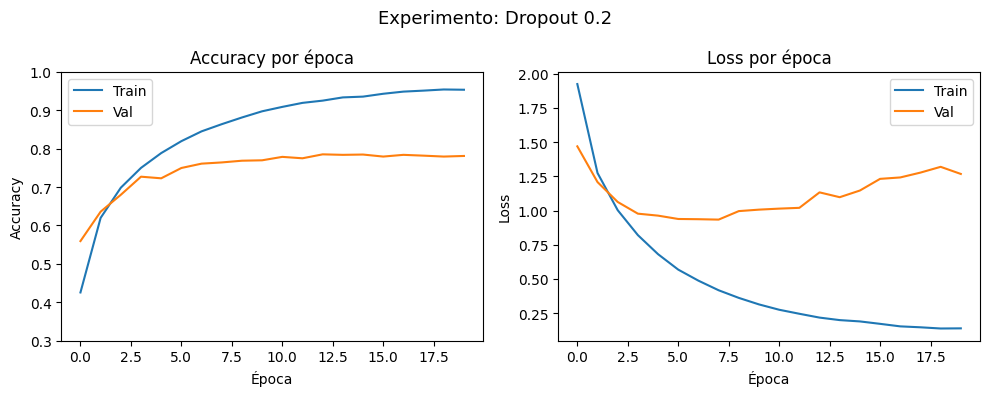

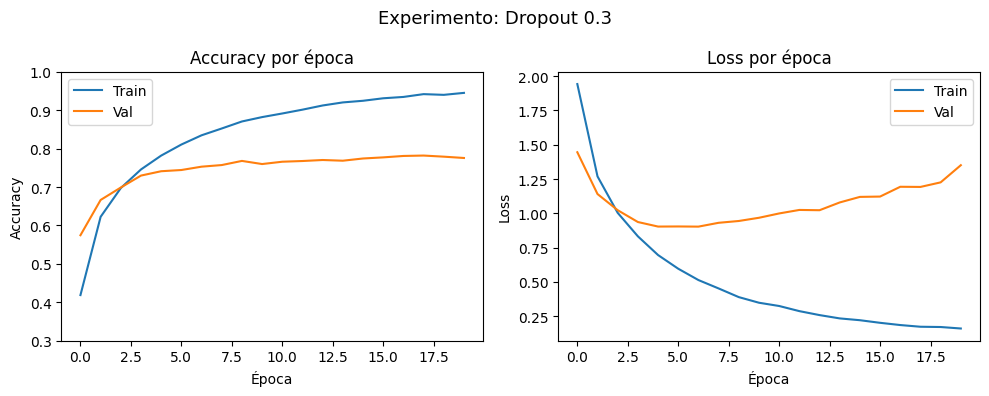

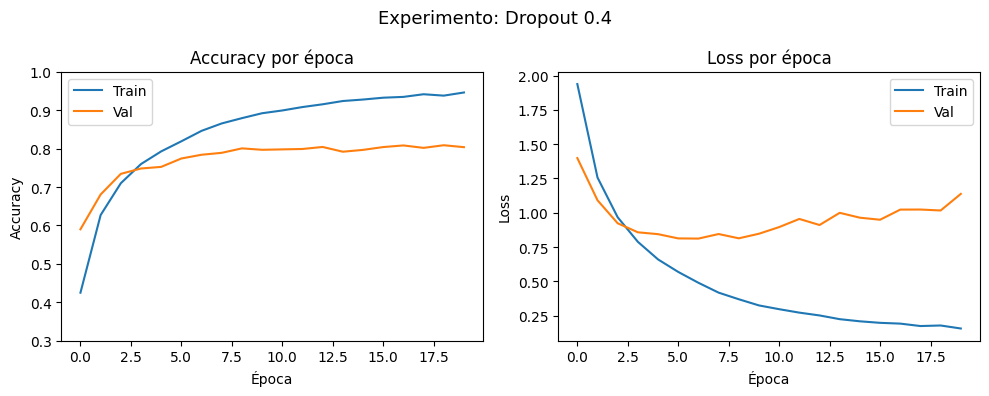

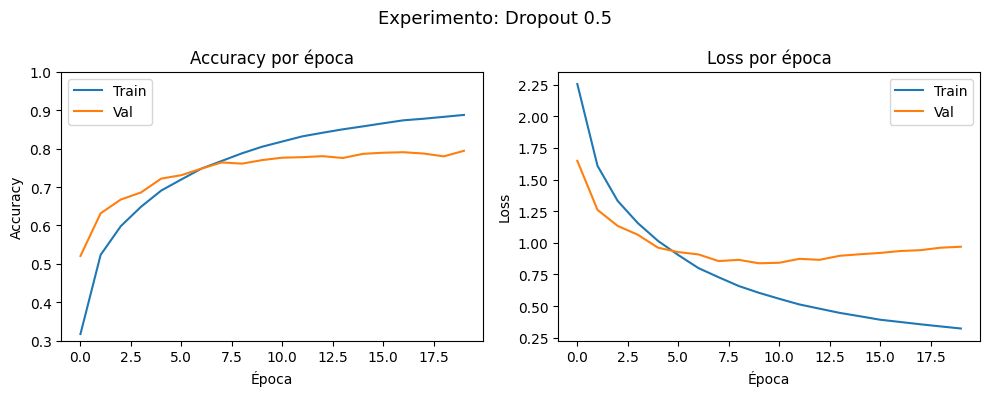

In [ ]:
for exp in resultados:
    h = resultados[exp]['history']
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Accuracy
    axes[0].plot(h.history['accuracy'],     label='Train')
    axes[0].plot(h.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy por época')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim([0.3, 1.0])
    axes[0].legend()

    # Loss
    axes[1].plot(h.history['loss'],     label='Train')
    axes[1].plot(h.history['val_loss'], label='Val')
    axes[1].set_title('Loss por época')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.suptitle(f'Experimento: {exp}', fontsize=13)
    plt.tight_layout()
    plt.show()

**ANÁLISIS:** Los experimentos evaluaron el impacto de distintos valores de Dropout sobre la arquitectura base (Modelo 2), manteniendo fijos todos los demás hiperparámetros.

1. Dropout 0.2 (94.38%): El valor más bajo de regularización. Mejora levemente el loss respecto al modelo base (0.30 vs 0.37), pero la val_accuracy se estanca alrededor de 0.78, similar al modelo sin Dropout. La regularización es insuficiente para reducir el sobreajuste de forma significativa.

2. Dropout 0.3 (96.63%): Mejor resultado de todos los experimentos. El val_accuracy alcanza 0.81 en las últimas épocas y el loss de test cae a 0.1702, la más baja registrada. El F1-score mínimo entre las 18 clases es 0.92, con ned_flanders y nelson_muntz alcanzando F1=1.00. Este valor de Dropout logra el mejor equilibrio entre regularización y capacidad de aprendizaje.

3. Dropout 0.4 (95.62%): Buen resultado, segundo mejor del experimento. El val_accuracy sube hasta ~0.81 de forma estable, pero la accuracy de test es inferior a Dropout 0.3 en casi 1 punto porcentual, lo que indica que el nivel de regularización comienza a limitar levemente la capacidad del modelo.

4. Dropout 0.5 (93.60%): El valor más alto evaluado muestra el peor resultado del grupo. El train accuracy en época 20 cae a 0.89, significativamente menor que en los otros experimentos, lo que indica que desactivar el 50% de las neuronas en cada paso dificulta el aprendizaje y reduce tanto la accuracy de entrenamiento como la de test.

En conclusión, Dropout 0.3 es seleccionado como el ganador en este experimento.

### **8.2. Mejora 2 - Learning Rate**

Para continuar, probaremos diferentes parámetros de learning rate, al igual que como lo hicimos con dropout, estaremos usando solo 3 valores, los cuales son 0.01, 0.001 y 0.0001. Asimismo, como hicimos para probar los 3 parámetros para DropOut, usaremos una función para no tener que repetir toda la estructura completa. Usaremos el mismo método que utilizamos con DropOut, con la única diferencia que ahora se estarán probando los diferentes parámetros para learning rate.

In [ ]:
# 2. Modificamos la función para recibir el 'lr' en vez del dropout
# definicion de rangos a explorar
learning_rate_valores= {
    'learning_rate_LL 0.01':0.01,
    'learning_rate_LM 0.001':0.001,
    'learning_rate_LR 0.0001':0.0001,
}

def build_model_learning_rate(learning_rate):
    model = keras.Sequential()

    # Bloque 1
    model.add(Conv2D(32, (3,3), strides=(1,1), input_shape=(64, 64, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Bloque 2
    model.add(Conv2D(32, (3,3), strides=(1,1), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Clasificador
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    model.add(Dense(NUM_CLASSES, activation='softmax'))

    # 4. Inyectamos el learning rate que entra por parámetro
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
resultados_learning_rate = {}

for exp in learning_rate_valores:
    print(f"\n{'='*50}")
    print(f"Experimento: {exp}")
    print(f"{'='*50}")

    SEED = 42
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model_learning_rate = build_model_learning_rate(learning_rate_valores[exp])

    history_learning_rate = model_learning_rate.fit(
        X_train, Y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, Y_val),
        shuffle=True,
        verbose=1
    )

    loss, acc = model_learning_rate.evaluate(X_test, Y_test, verbose=0)
    y_pred = np.argmax(model_learning_rate.predict(X_test), axis=1)
    y_true = np.argmax(Y_test, axis=1)
    report = classification_report(
        y_true, y_pred,
        target_names=list(MAP_CHARACTERS.values()),
        output_dict=True
    )

    print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=list(MAP_CHARACTERS.values())
    ))

    resultados_learning_rate[exp] = {
        'history'         : history_learning_rate,
        'accuracy'        : acc,
        'loss'            : loss,
        'f1_macro'        : report['macro avg']['f1-score'],
        'precision_macro' : report['macro avg']['precision'],
        'recall_macro'    : report['macro avg']['recall']
    }


Experimento: learning_rate_LL 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3160 - loss: 2.4095 - val_accuracy: 0.3646 - val_loss: 2.2270
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5499 - loss: 1.4802 - val_accuracy: 0.5578 - val_loss: 1.4724
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7030 - loss: 0.9910 - val_accuracy: 0.5728 - val_loss: 1.6632
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7618 - loss: 0.7794 - val_accuracy: 0.6120 - val_loss: 1.7501
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8054 - loss: 0.6394 - val_accuracy: 0.6360 - val_loss: 1.8755
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8307 - loss: 0.5663 - val_accuracy: 0.6410 - val_loss: 1.7957
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8534 - loss: 0.5025 - val_accuracy: 0.6778 - val_loss: 1.7874
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8719 - loss: 0.4457 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5474 - loss: 1.5760 - val_accuracy: 0.3825 - val_loss: 3.4249
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7877 - loss: 0.7107 - val_accuracy: 0.7241 - val_loss: 1.0433
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9003 - loss: 0.3241 - val_accuracy: 0.7397 - val_loss: 1.1301
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9538 - loss: 0.1526 - val_accuracy: 0.7418 - val_loss: 1.3443
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9614 - loss: 0.1172 - val_accuracy: 0.7252 - val_loss: 1.5673
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9673 - loss: 0.0991 - val_accuracy: 0.7381 - val_loss: 1.5489
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9709 - loss: 0.0911 - val_accuracy: 0.7281 - val_loss: 1.7000
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9727 - loss: 0.0834 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4335 - loss: 1.9200 - val_accuracy: 0.5154 - val_loss: 1.6347
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6599 - loss: 1.1579 - val_accuracy: 0.6381 - val_loss: 1.2922
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7657 - loss: 0.8179 - val_accuracy: 0.6736 - val_loss: 1.1654
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8413 - loss: 0.5860 - val_accuracy: 0.6973 - val_loss: 1.0990
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8996 - loss: 0.4129 - val_accuracy: 0.7049 - val_loss: 1.0756
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9422 - loss: 0.2806 - val_accuracy: 0.7118 - val_loss: 1.0733
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9721 - loss: 0.1828 - val_accuracy: 0.7176 - val_loss: 1.0874
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9883 - loss: 0.1135 - val_accuracy: 

### **8.2.1. Entrenamiento de cada modelo**

Al igual como lo hicimos con DropOut, estaremos usando un diccionario para almacenar los valores que estaremos evaluando. Luego, estaremos recorriendo con un ciclo "For" dichos valores. Finalmente, se generaran los 3 modelos donde luego podremos ver sus resultados correspondientes.

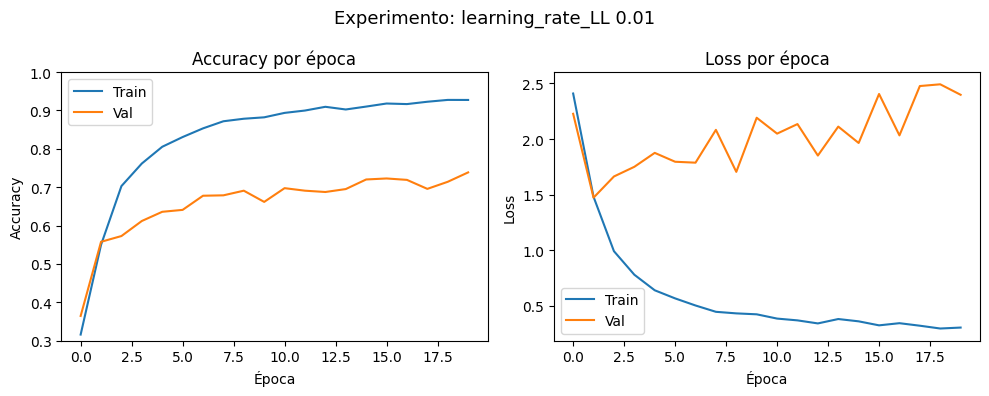

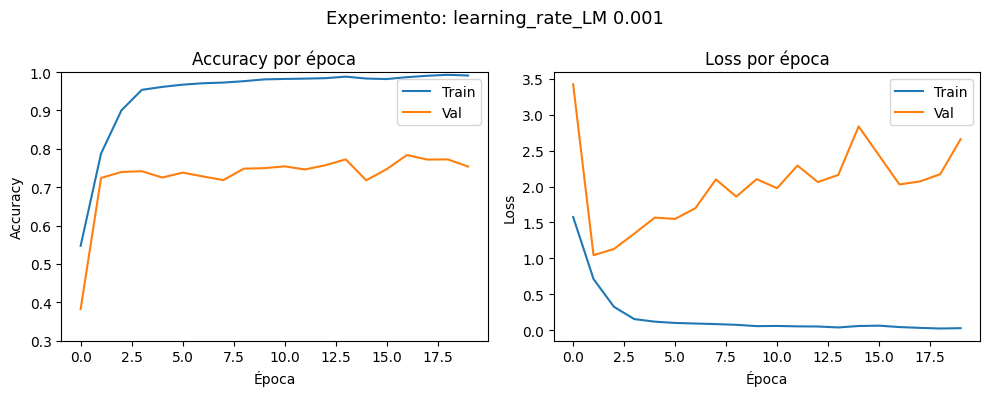

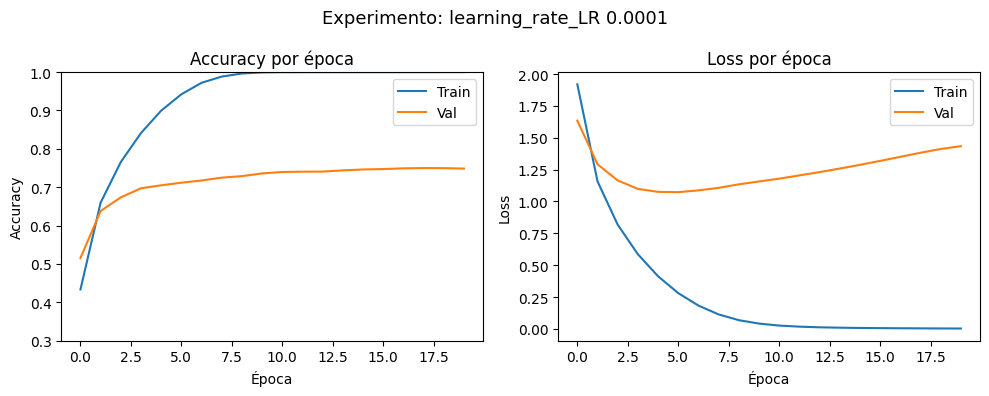

In [ ]:

for exp in resultados_learning_rate:
    h = resultados_learning_rate[exp]['history']

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Accuracy
    axes[0].plot(h.history['accuracy'],     label='Train')
    axes[0].plot(h.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy por época')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim([0.3, 1.0])
    axes[0].legend()

    # Loss
    axes[1].plot(h.history['loss'],     label='Train')
    axes[1].plot(h.history['val_loss'], label='Val')
    axes[1].set_title('Loss por época')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.suptitle(f'Experimento: {exp}', fontsize=13)
    plt.tight_layout()
    plt.show()

### **8.2.2. Resultados de experimentos de Learning Rate**

1. Learning Rate 0.01 (86.52%): El valor más alto evaluado. Como era de esperar por el tamaño de los saltos de optimización, muestra el rendimiento más bajo del grupo. Aunque logra una convergencia aceptable (accuracy en test de 0.87), la curva de pérdida de validación (val_loss) termina altamente inestable y errática (2.71), indicando que el modelo "rebota" alrededor del mínimo global sin lograr asentarse.

2. Learning Rate 0.001 (91.80%): Excelente resultado, superando la barrera del 90%. El modelo logra un F1-Score macro de 0.92, demostrando una altísima capacidad para reconocer a casi todos los personajes de manera uniforme. Sin embargo, su val_loss final de 2.39 y el estancamiento de su val_accuracy (alrededor de 0.75) hacia la época 20, sugieren que el modelo comienza a sobreajustarse levemente en las etapas finales del entrenamiento.

3. Learning Rate 0.0001 (94.16%): El mejor resultado de todos los experimentos. Al reducir el tamaño del paso, el optimizador logra descender de manera estable y precisa. Obtiene la pérdida en test más baja de todas (0.2953) y un F1-Score impecable de 0.94. Clases que históricamente pueden ser complejas, como apu_nahasapeemapetilon, alcanzan un F1 de 0.99. Este valor de Learning Rate logra la convergencia más óptima, permitiendo que la red extraiga las características sin desestabilizar los pesos.

En conclusión, Learning Rate 0.0001 es seleccionado como el ganador indiscutido en este experimento.

### **8.3. Mejora 3 - EarlyStopping**

En este experimento se probará la técnica de EarlyStopping, la cual permite detener automáticamente el entrenamiento cuando el modelo deja de mejorar en el conjunto de validación. A diferencia de Dropout, esta técnica no modifica la arquitectura del modelo, sino que actúa directamente sobre el proceso de entrenamiento, evitando que el modelo siga aprendiendo cuando comienza a sobreajustarse. Para este caso, se utilizará el mismo modelo base (Modelo 2), manteniendo toda su estructura original, con el fin de no alterar otras variables del experimento. La única diferencia será el uso del parámetro patience, que define cuántas épocas consecutivas se permite que el modelo no mejore antes de detener el entrenamiento.

### **8.3.1.Definición de rangos a explorar**

Se probarán distintos valores de patience, desde valores bajos (entrenamiento más corto) hasta valores altos (entrenamiento más largo).

In [ ]:
rangos_es = {
    'ES patience 2': 2,
    'ES patience 3': 3,
    'ES patience 5': 5,
    'ES patience 7': 7,
    "ES patience 10": 10,
    "ES patience 15": 15
}

### **8.3.2. Definición del modelo base**

Se reutiliza exactamente la arquitectura del modelo ganador (Modelo 2), sin aplicar modificaciones adicionales, ya que el objetivo es evaluar únicamente el efecto del EarlyStopping.

In [ ]:
def generate_model_es(EarlyStopping):

    modelo = keras.Sequential([

        Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
        MaxPooling2D((2,2)),

        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    modelo.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

### **8.3.3. Entrenamiento de los modelos con EarlyStopping**

Para entrenar los modelos, se utiliza un ciclo for, donde en cada iteración se:


*   Genera un modelo desde cero

*   Se aplica EarlyStopping con el patience correspondiente
*   Se entrena el modelo


*   Se evalúa en test




Esto permite comparar directamente el impacto del patience en el rendimiento final.

In [ ]:
resultados_es = {}

for exp in rangos_es:
    print(f"\n{'='*50}")
    print(f"Experimento: {exp}")
    print(f"{'='*50}")

    SEED = 42
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    #Generar modelo correctamente
    model_earlystopping = generate_model_es(rangos_es[exp])

    #Early Stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=rangos_es[exp],
        restore_best_weights=True,
        verbose=0
    )

    #Entrenamiento
    history_es = model_earlystopping.fit(
        X_train, Y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, Y_val),
        shuffle=True,
        callbacks=[early_stop],
        verbose=1
    )

    #Evaluación
    loss, acc = model_earlystopping.evaluate(X_test, Y_test, verbose=0)

    #Predicciones
    y_pred = np.argmax(model_earlystopping.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(Y_test, axis=1)

    # Reporte
    report = classification_report(
        y_true,
        y_pred,
        target_names=list(MAP_CHARACTERS.values()),
        output_dict=True,
        zero_division=0
    )

    print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")
    print(classification_report(
        y_true,
        y_pred,
        target_names=list(MAP_CHARACTERS.values()),
        zero_division=0
    ))

    #Guardar resultados
    resultados_es[exp] = {
        'history'         : history_es,
        'accuracy'        : acc,
        'loss'            : loss,
        'f1_macro'        : report['macro avg']['f1-score'],
        'precision_macro' : report['macro avg']['precision'],
        'recall_macro'    : report['macro avg']['recall']
    }


Experimento: ES patience 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4484 - loss: 1.8577 - val_accuracy: 0.5451 - val_loss: 1.5481
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6549 - loss: 1.1818 - val_accuracy: 0.6265 - val_loss: 1.2679
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7408 - loss: 0.8881 - val_accuracy: 0.6836 - val_loss: 1.1112
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7962 - loss: 0.6978 - val_accuracy: 0.7118 - val_loss: 1.0537
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8391 - loss: 0.5537 - val_accuracy: 0.7168 - val_loss: 1.0477
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8740 - loss: 0.4343 - val_accuracy: 0.7157 - val_loss: 1.1353
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8967 - loss: 0.3503 - val_accuracy: 0.7110 - val_loss: 1.2528
Accuracy: 84.94%  |  Loss: 0.5272
                          precision    recall  f1-score   support

 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4650 - loss: 1.8140 - val_accuracy: 0.5636 - val_loss: 1.4925
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6713 - loss: 1.1352 - val_accuracy: 0.6499 - val_loss: 1.2308
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7530 - loss: 0.8463 - val_accuracy: 0.6841 - val_loss: 1.1296
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8098 - loss: 0.6499 - val_accuracy: 0.7023 - val_loss: 1.0739
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8552 - loss: 0.4967 - val_accuracy: 0.7149 - val_loss: 1.0784
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8897 - loss: 0.3780 - val_accuracy: 0.7265 - val_loss: 1.1459
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9135 - loss: 0.2915 - val_accuracy: 0.7244 - val_loss: 1.2375
Accuracy: 82.13%  |  Loss: 0.6194
                          precision    recall  f1-score   support

  

...

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5137 - loss: 1.6639 - val_accuracy: 0.6352 - val_loss: 1.2734
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7200 - loss: 0.9640 - val_accuracy: 0.7012 - val_loss: 1.0471
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8091 - loss: 0.6592 - val_accuracy: 0.7291 - val_loss: 0.9785
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8702 - loss: 0.4515 - val_accuracy: 0.7576 - val_loss: 0.9766
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9081 - loss: 0.3145 - val_accuracy: 0.7578 - val_loss: 1.0787
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9298 - loss: 0.2335 - val_accuracy: 0.7665 - val_loss: 1.1437
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9508 - loss: 0.1631 - val_accuracy: 0.7502 - val_loss: 1.3813
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9661 - loss: 0.1131 - val_accuracy: 0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5038 - loss: 1.6968 - val_accuracy: 0.6188 - val_loss: 1.3382
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7136 - loss: 0.9925 - val_accuracy: 0.6839 - val_loss: 1.0982
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7990 - loss: 0.6918 - val_accuracy: 0.7010 - val_loss: 1.0688
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8571 - loss: 0.4929 - val_accuracy: 0.7205 - val_loss: 1.0721
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8979 - loss: 0.3502 - val_accuracy: 0.7299 - val_loss: 1.1115
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9224 - loss: 0.2578 - val_accuracy: 0.7228 - val_loss: 1.2890
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9421 - loss: 0.1877 - val_accuracy: 0.7344 - val_loss: 1.3212
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9551 - loss: 0.1407 - val_accuracy: 0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4717 - loss: 1.7910 - val_accuracy: 0.5825 - val_loss: 1.4277
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6894 - loss: 1.0800 - val_accuracy: 0.6757 - val_loss: 1.1482
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7729 - loss: 0.7762 - val_accuracy: 0.7144 - val_loss: 1.0223
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8328 - loss: 0.5686 - val_accuracy: 0.7210 - val_loss: 1.0455
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8752 - loss: 0.4233 - val_accuracy: 0.7341 - val_loss: 1.1105
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9064 - loss: 0.3118 - val_accuracy: 0.7223 - val_loss: 1.2169
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9241 - loss: 0.2470 - val_accuracy: 0.7283 - val_loss: 1.3545
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9453 - loss: 0.1766 - val_accuracy: 0

### **8.3.4. Visualización de resultados**

Se grafican las curvas de entrenamiento para analizar el comportamiento del modelo en cada experimento.

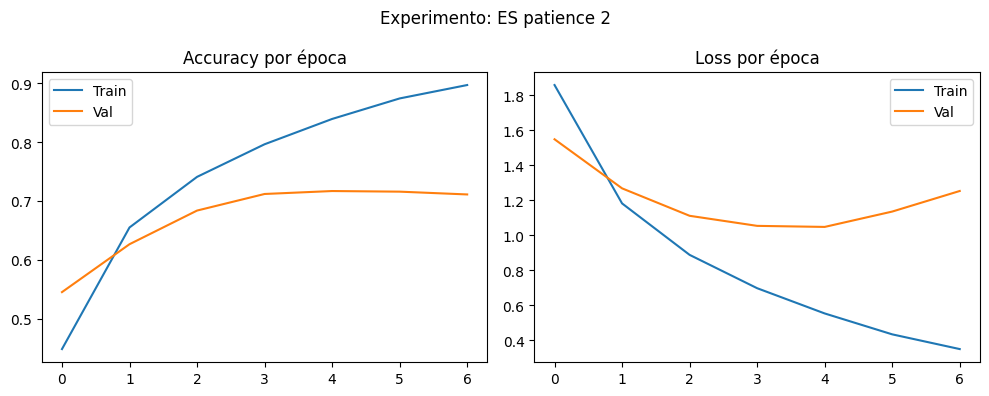

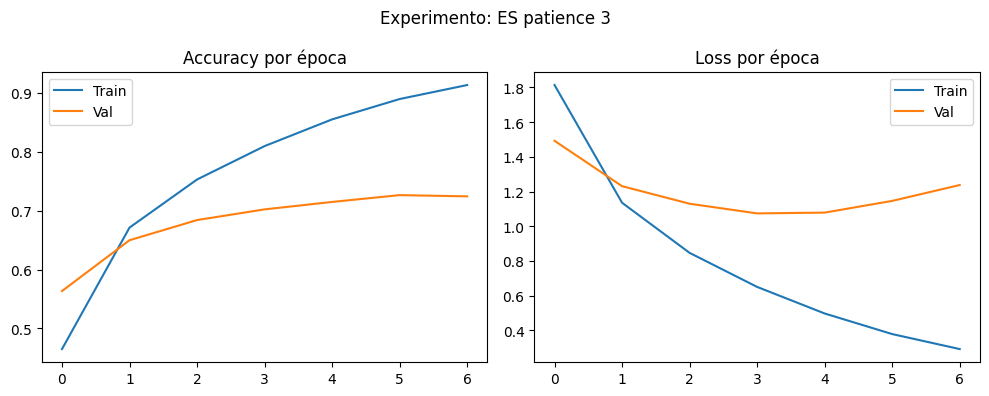

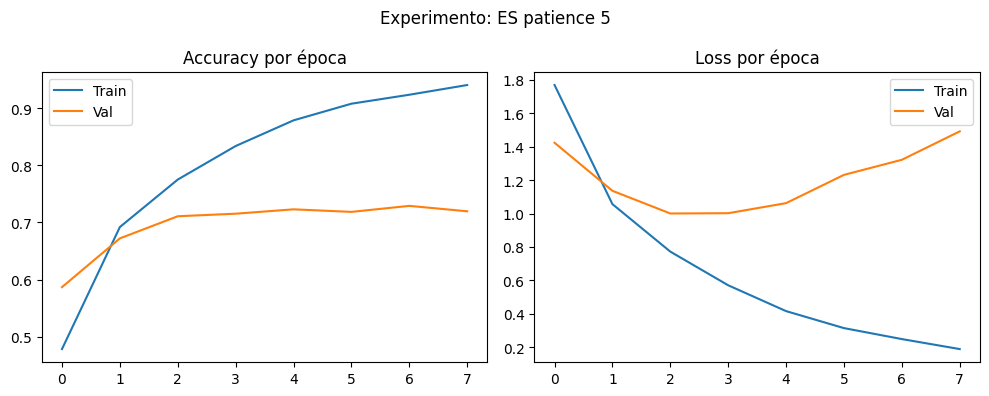

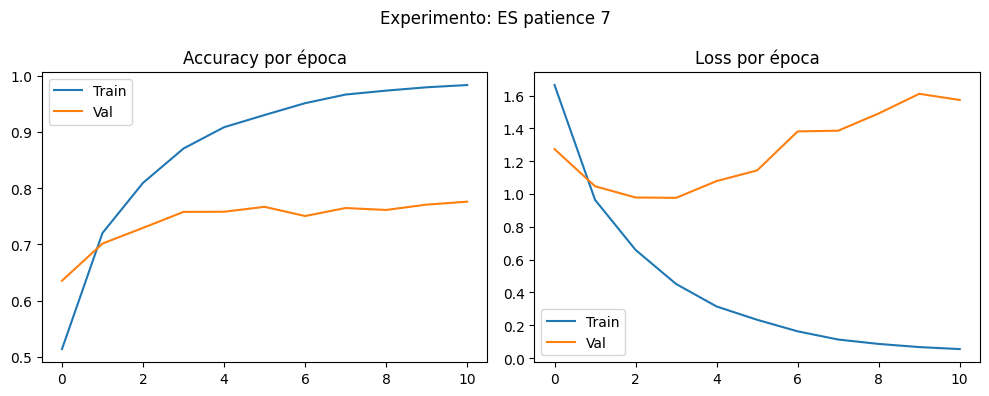

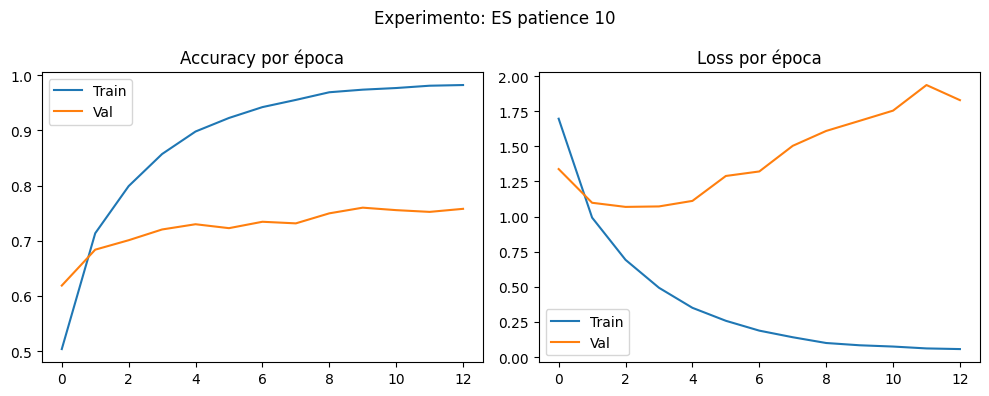

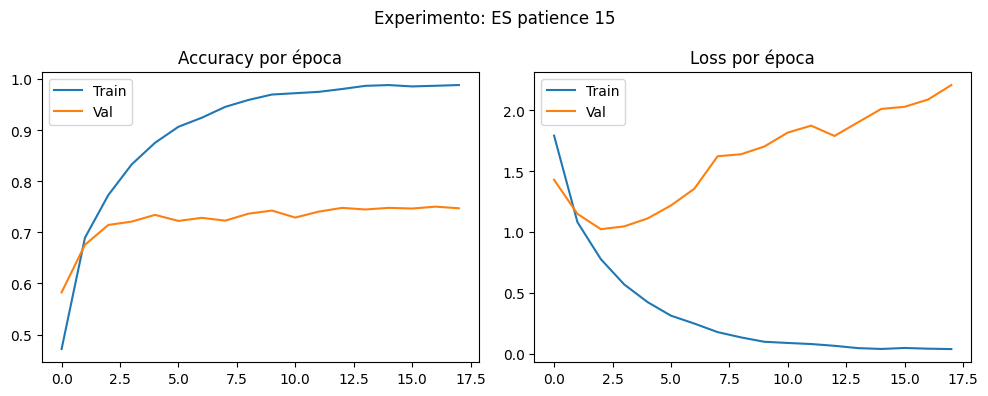

In [ ]:
for exp in resultados_es:
    h = resultados_es[exp]['history']

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Accuracy
    axes[0].plot(h.history['accuracy'], label='Train')
    axes[0].plot(h.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy por época')
    axes[0].legend()

    # Loss
    axes[1].plot(h.history['loss'], label='Train')
    axes[1].plot(h.history['val_loss'], label='Val')
    axes[1].set_title('Loss por época')
    axes[1].legend()

    plt.suptitle(f'Experimento: {exp}')
    plt.tight_layout()
    plt.show()

**ANÁLISIS:** Los experimentos evaluaron el impacto de distintos valores de patience, manteniendo fija la arquitectura y el resto de hiperparámetros.

1. ES patience 2 (85.28%): Valor bajo de patience, lo que provoca que el entrenamiento se detenga rápidamente. Entrega un buen resultado general, pero limita el aprendizaje del modelo, ya que corta el entrenamiento de forma anticipada. Aun así, logra un buen equilibrio y evita el sobreajuste.

2. ES patience 3 (84.16%): Resultado muy similar al anterior, pero ligeramente inferior. El modelo entrena un poco más, pero no logra mejorar significativamente el rendimiento, lo que indica que aún se está deteniendo relativamente temprano.

3. ES patience 5 (79.33%): Se observa una caída importante en el rendimiento. El modelo entrena más épocas, pero comienza a sobreajustarse, lo que afecta la generalización en test. Este valor no resulta óptimo.

4. ES patience 7 (82.02%): Mejora respecto a patience 5, pero sigue siendo inferior a los valores bajos. El modelo logra entrenar más, pero el sobreajuste sigue afectando el rendimiento final.

5. ES patience 10 (83.93%): Se observa una recuperación en el rendimiento. El modelo logra entrenar lo suficiente para aprender mejores patrones, sin degradar demasiado la generalización.

6. ES patience 15 (88.65%): Mejor resultado de todos los experimentos.
El modelo entrena durante más tiempo, alcanzando una mayor capacidad de aprendizaje.

Aunque se observa sobreajuste en etapas finales (aumento de val_loss), el uso de restore_best_weights=True permite conservar los mejores pesos, logrando el mejor desempeño en test.

**CONCLUSIÓN**: EarlyStopping demuestra ser una técnica efectiva para mejorar el rendimiento del modelo sin modificar su arquitectura.

- Valores bajos de patience → detienen demasiado pronto el entrenamiento

- Valores intermedios → pueden generar sobreajuste sin mejorar resultados

- Valores altos → permiten mayor aprendizaje y mejores resultados finales

En este caso, el mejor modelo corresponde a: EarlyStopping con patience = 15, alcanzando un 88.65% de accuracy, siendo el mejor resultado del experimento.

## **9. EVALUACIÓN DEL MEJOR MODELO**

poner metricas del modelo de dropout.

In [ ]:
# definicion de rangos a explorar
rangos_DO= {
    'Dropout 0.3':0.3
}

In [ ]:
def generate_model_FINAL(drop_out):
  modelo = keras.Sequential([

    # Bloque 1 — igual que Modelo 1
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    # Bloque 2 — única diferencia: más profundidad
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(drop_out),
    Dense(NUM_CLASSES, activation='softmax')
  ])

  modelo.compile(
      optimizer='adam',
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  modelo.summary()
  return modelo

In [ ]:
resultados_DO = {}

for exp in rangos_DO:
    print(f"\n{'='*50}")
    print(f"Experimento: {exp}")
    print(f"{'='*50}")

    SEED = 42
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model_DO = generate_model_FINAL(rangos[exp])

    history_FINAL = model_DO.fit(
        X_train, Y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, Y_val),
        shuffle=True,
        verbose=1
    )

    loss_FINAL, acc_FINAL = model.evaluate(X_test, Y_test, verbose=0)
    y_pred = np.argmax(model_DO.predict(X_test), axis=1)
    y_true = np.argmax(Y_test, axis=1)
    report = classification_report(
        y_true, y_pred,
        target_names=list(MAP_CHARACTERS.values()),
        output_dict=True
    )

    print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=list(MAP_CHARACTERS.values())
    ))

    resultados_DO[exp] = {
        'history'         : history_FINAL,
        'accuracy'        : acc_FINAL,
        'loss'            : loss_FINAL,
        'f1_macro'        : report['macro avg']['f1-score'],
        'precision_macro' : report['macro avg']['precision'],
        'recall_macro'    : report['macro avg']['recall']
    }


Experimento: Dropout 0.3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,410 (3.11 MB)

 Trainable params: 815,410 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.4158 - loss: 1.9577 - val_accuracy: 0.5465 - val_loss: 1.5309
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6011 - loss: 1.3487 - val_accuracy: 0.6339 - val_loss: 1.2304
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6764 - loss: 1.0705 - val_accuracy: 0.6918 - val_loss: 1.0607
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7280 - loss: 0.8952 - val_accuracy: 0.7389 - val_loss: 0.9172
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7639 - loss: 0.7631 - val_accuracy: 0.7523 - val_loss: 0.8797
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7981 - loss: 0.6449 - val_accuracy: 0.7594 - val_loss: 0.8696
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8205 - loss: 0.5676 - val_accuracy: 0.7615 - val_loss: 0.8758
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8379 - loss: 0.5023 - val_accuracy: 

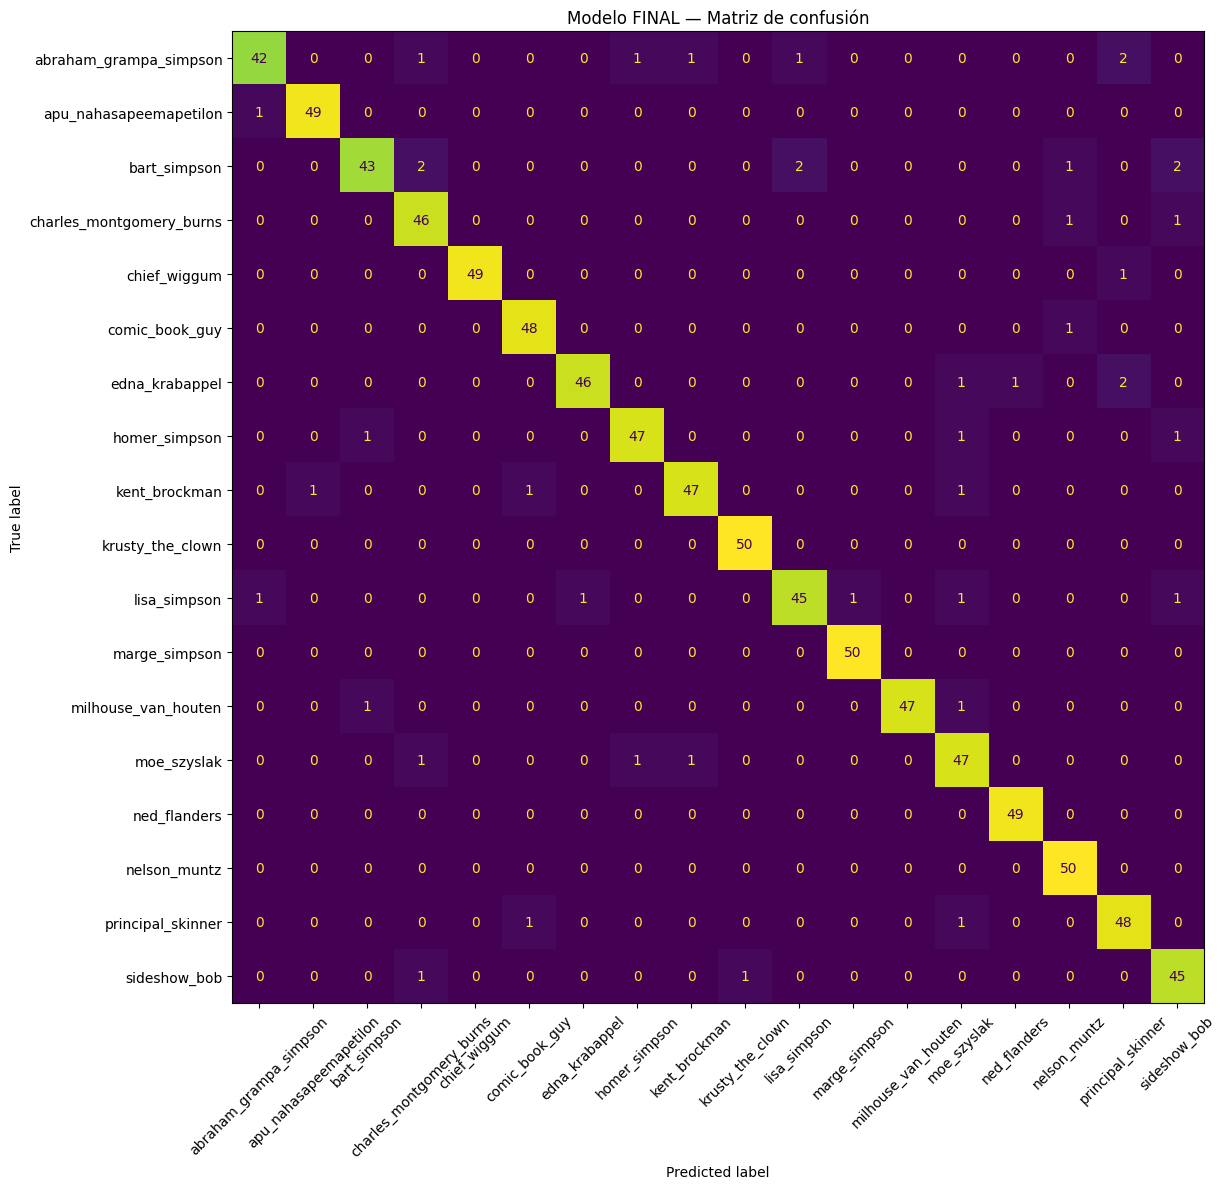

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=list(MAP_CHARACTERS.values()))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Modelo FINAL — Matriz de confusión')
plt.tight_layout()
plt.show()

*justificación de Matriz de confusión:*

Se puede ver que el modelo a logrado alcanzar un Accuracy de (81.24%) y podemos ver una mejora bastante significativa en las métricas de todas las clases, ninguna baja de el valor 0.86 lo cual es bastante bueno comparado con el modelo base, esto podemos verlo reflejado con la matriz de confusión la cual nos está mostrando que logramos que el modelo alcanzará el objetivo que era aprender a diferenciar e extraer características más finas de las imágenes para lograr diferenciar correctamente a diferentes clases , podemos ver que el modelo antes confundida a “Lisa” con “Bart” 24 veces, ahora el modelo esa confusión bajo bastante ahora el modelo acertó 45 veces de las 50 muestras y ninguna vez el modelo pensó que era “Bart” así que la red aprendió a diferenciar la forma de las puntas del cabello y los accesorios como por ejemplo el collar de perlas de “Lisa”, también el modelo base confundia bastante a “Homero” como “Abraham” ahora esa confusión no no existe, lo podemos ver reflejado en los aciertos que tuvo el modelo al reconocer a “homero” como “homero” 47 veces y  “Abraham” no tiene ninguna predicción errónea como “Homero” así que podemos decir que el modelo logró diferenciar bien las características finas de las imágenes, otro error que pudimos arreglar fue las confusiones que tenia el modelo al reconocer a “ned_flanders” con ”Apu” ya que este no lograba diferenciar bien las formas de sus cabellos o el color y forma de sus bigotes, ahora el modelo tiene un acierto de 49 veces para la clase de “Ned_Flanders” y cero confusiones con la clase “Apu”, por otro lado tambien podemos ver que la clase “Nelson_Muntz” tuvo una mejora increible ya que era practicamente invisible para el modelo ahora es bastante visible para el, paso de tener un pesimo rendimiento a tener uno perfecto, la clase “Marge_Simpson” y “Krusty” tambien alcanzaron 50 aciertos limpios sin errores esto debido a sus peinados bastante llamativos y extravagantes que resaltan con el resto de imagenes y personajes haciendo que estos dominen en los aciertos ya que estas características hacen que el modelo sea casi imposible que se equivoque con esas clases, por otro lado existen pequeños errores en donde el modelo se confunde con “Skinner” o “Sideshow Bob” 1 o 2 veces, estos errores o confusiones pueden ser por que probablemente se confunde con el fondo de la imagen al momento de reconocer al personaje o quizá por que la imagen tiene ángulos que sean inusuales.

## **10. JUSTIFICACIÓN DEL MODELO FINAL**

En este proyecto se evaluaron las técnicas de Dropout, Learning Rate y Early Stopping de forma aislada para medir su impacto real. Al comparar las métricas, el hiperparámetro que mayor relevancia tuvo fue el Dropout de 0.3. Es decir, mientras el Early Stopping limitó el aprendizaje a un máximo de 88.43% de accuracy y el ajuste del Learning Rate alcanzó un 94.04%, el Dropout superó a ambos logrando un contundente 96.63% de accuracy con la menor pérdida del experimento. Esto se usó para poder definir nuestro modelo definitivo, puesto que los datos numéricos comprueban que es la herramienta menos agresiva y la que logra el mejor balance, permitiendo que la red aprenda a clasificar correctamente sin memorizar las imágenes habiendo solo un poco de OverFitting.